#### Dependencies

In [1]:
pip install gensim spacy torchtext==0.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.7 MB/s eta 0:00:00


In [2]:
!pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# Part 0. Dataset Preparation

**Code given from assignment brief**

from torchtext import data, datasets<br>
import torch<br>
\# For tokenization<br>
TEXT = data.Field(tokenize = 'spacy', tokenizer_language = 'en_core_web_sm', include_lengths = True)<br>
\# For multi-class classification labels<br>
LABEL = data.LabelField()<br>
\# Load the TREC dataset<br>
train_data, test_data = datasets.TREC.splits(TEXT, LABEL, fine_grained = False)<br>

In [3]:
from torchtext import data, datasets
import random
import torch

In [4]:
# Tokenizer & fields
TEXT = data.Field(tokenize='spacy',
                  tokenizer_language='en_core_web_sm',
                  include_lengths=False)
LABEL = data.LabelField()


In [5]:
# Loading the TREC dataset
train_data, test_data = datasets.TREC.splits(TEXT, LABEL, fine_grained=False)
print(f"Total training examples: {len(train_data)}")
print(f"Total test examples: {len(test_data)}")

downloading train_5500.label


train_5500.label: 100%|██████████| 336k/336k [00:00<00:00, 1.16MB/s]


downloading TREC_10.label


TREC_10.label: 100%|██████████| 23.4k/23.4k [00:00<00:00, 459kB/s]


Total training examples: 5452
Total test examples: 500


In [6]:
# Splitting data to training and validation sets
train_data, valid_data = train_data.split(split_ratio=0.8, random_state=random.seed(42))
print(f"Training examples: {len(train_data)}")
print(f"Validation examples: {len(valid_data)}")

Training examples: 4362
Validation examples: 1090


In [7]:
# Batch data for later
from torchtext.data import BucketIterator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_iterator, valid_iterator = BucketIterator.splits(
    (train_data, valid_data),
    batch_size = 64,
    sort_within_batch = True,        # Groups sentences of similar length
    sort_key=lambda x: len(x.text),  # Sorting key
    device = device
)

# Create test iterator
test_iterator = BucketIterator(
    test_data,
    batch_size=64,
    sort=False,  # no need to sort for evaluation
    device=device
)

# Part 1. Preparing Word Embeddings

## Q1a. Size of vocabulary

In [8]:
# Building the vocabulary
TEXT.build_vocab(train_data)
LABEL.build_vocab(train_data)
print(f"Unique tokens in TEXT vocabulary: {len(TEXT.vocab)}")
print(f"Unique labels: {len(LABEL.vocab)}")

Unique tokens in TEXT vocabulary: 8093
Unique labels: 6


Notes to self:
    <p>Word2Vec : train a neural network to predict the context words given a target word, and use the <br>
    resulting vector representations to capture the semantic meaning of the words. (Captures semantic <br>
    relationships between words using Continuous Bag of Words (CBOW) and Skip-gram).
    <p> CBOW: Using surrounding context words, predict target word. </p>
    <p> Skip-gram: Predicts the surrounding context words given a target word.</p>
    PROS: Captures semantic relationships between words, lower dimensionality than classical methods <br>
    CONS: Requires training on a large corpus, does not handle OOV words well.
    <p>Glove: Unsupervised learning algorithm, aims to capture both global word co-occurence statistics and local  context window-based information (like Word2Vec) to create high-quality word vectors. </p>
    PROS: Captures both global and local context, FASTER training than Word2Vec. <br>
    CONS: Out-of-Vocab words, same as Word2Vec

## Q1c. Change while testing

We do Q1c before Q1b so that we can directly compare our solution's improved result with the original result.

For the min_count below, by changing the min_count to more than 1, it will allow the quality of the embedding to be better.
Best strategy is to increase the min_count so that the overlapping sets will not have a high amount of Out-Of-Vocab words.

Will be utilizing Skip-gram for updating the vectors

In [9]:
import gensim.downloader as api

# Load pretrained Google News Word2Vec
print("Loading pretrained Google News Word2Vec (300d)...")
w2v_google = api.load("word2vec-google-news-300")
print(f"Loaded Google News vectors: {len(w2v_google.key_to_index)} words")

Loading pretrained Google News Word2Vec (300d)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded Google News vectors: 3000000 words


In [10]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
# (Q1c) Train a local Word2Vec model on the TREC dataset
from gensim.models import Word2Vec
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

sentences = [ex.text for ex in train_data]
print("Training local Word2Vec on TREC dataset...")
w2v_local = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,               # Context window size 2 left and 2 right
    min_count=1,            # Set to 1 to include all words in small dataset
    sg=1,                   # Using skip-gram
    workers=4,              # Amount of CPU cores to use
    epochs=20,
)

local_vectors = w2v_local.wv
print(f"Local Word2Vec vocab size: {len(local_vectors.key_to_index)}")

Training local Word2Vec on TREC dataset...
Local Word2Vec vocab size: 8091


(Q1c) Combining the Google pre-trained model with the locally trained model (with the change of min_count to be more than 1)

Google's pre-trained model already has a min_count of 5, but this is trained to generically provide for the common English terms. But for this locally trained model, since we are focusing more on TREC questions, we are supplying it domain-specific embeddings.

So by creating a hybrid embedding, it would reduce the Out-Of-Vocab occurrences while maintaining a high semantic fidelity as it is confident and will be much more accurate on the reported data.

In [12]:
import numpy as np

def build_hybrid_embedding_matrix(vocab, w2v_google, w2v_local, dim=300):

    matrix = np.zeros((len(vocab), dim), dtype=np.float32)
    google_mean = np.mean(w2v_google.vectors, axis=0)   # 1 s or less

    for i, word in enumerate(vocab):
        if word in w2v_google.key_to_index:
            matrix[i] = w2v_google[word]
        elif word in w2v_local.wv.key_to_index:
            matrix[i] = w2v_local.wv[word]
        else:
            matrix[i] = google_mean

    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix_hybrid = build_hybrid_embedding_matrix(TEXT.vocab.itos, w2v_google, w2v_local)
print("Hybrid embedding matrix shape:", embedding_matrix_hybrid.shape)

Hybrid embedding matrix shape: torch.Size([8093, 300])


## Q1b. Number of OOV words

In [ ]:
google_only = 0
local_only = 0
missing = 0

for w in TEXT.vocab.itos:
    if w in w2v_google.key_to_index:
        google_only += 1
    elif w in w2v_local.wv.key_to_index:
        local_only += 1
    else:
        missing += 1

print(f"Words covered by Google News: {google_only}")
print(f"Words covered by Local Model: {local_only}")
print(f"Still missing (mean vector used): {missing}")
print(f"Coverage improved to {(google_only + local_only)/len(TEXT.vocab)*100:.2f}%")

Words covered by Google News: 7665
Words covered by Local Model: 426
Still missing (mean vector used): 2
Coverage improved to 99.98%


In [ ]:
from collections import defaultdict

oov_by_topic = defaultdict(set)
total_oov_count = 0

for example in train_data:
    label = example.label
    for token in example.text:
        t = token.lower()
        if (t not in w2v_google.key_to_index) and (t not in w2v_local.wv.key_to_index):
            oov_by_topic[label].add(t)
            total_oov_count += 1

if not oov_by_topic:
    print("No OOV words found in training data.")
else:
    print(f"Total unique OOV words: {sum(len(v) for v in oov_by_topic.values())}")
    for topic, words in oov_by_topic.items():
        print(f"{topic}: {len(words)} OOV words → {list(words)[:5]}")



Total unique OOV words: 819
NUM: 105 OOV words → ['frommer', 'aldous', 'biloxi', 'bernadette', 'maurizio']
LOC: 153 OOV words → ['firehole', 'cawdor', 'sheboygan', 'ericson', 'nnp']
DESC: 109 OOV words → ['minow', 'smartnet', 't.', 'elysium', 'toulmin']
ENTY: 194 OOV words → ['bergen', 'nnp', 'hallie', 'mrs.', 'doxat']
HUM: 237 OOV words → ['doonesbury', 'merrick', 'hansel', 'astaire', 'harriet']
ABBR: 21 OOV words → ['t.s.', 'g.m.t.', 'r.e.m.', 'ms.', 'mikhail']


## Q1d. Visualisation with PCA first and then t-SNE

Running PCA -> 50D...
Running t-SNE -> 2D (this may take a few minutes)...


C:\Users\rache\AppData\Local\Temp\ipykernel_26812\392069505.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


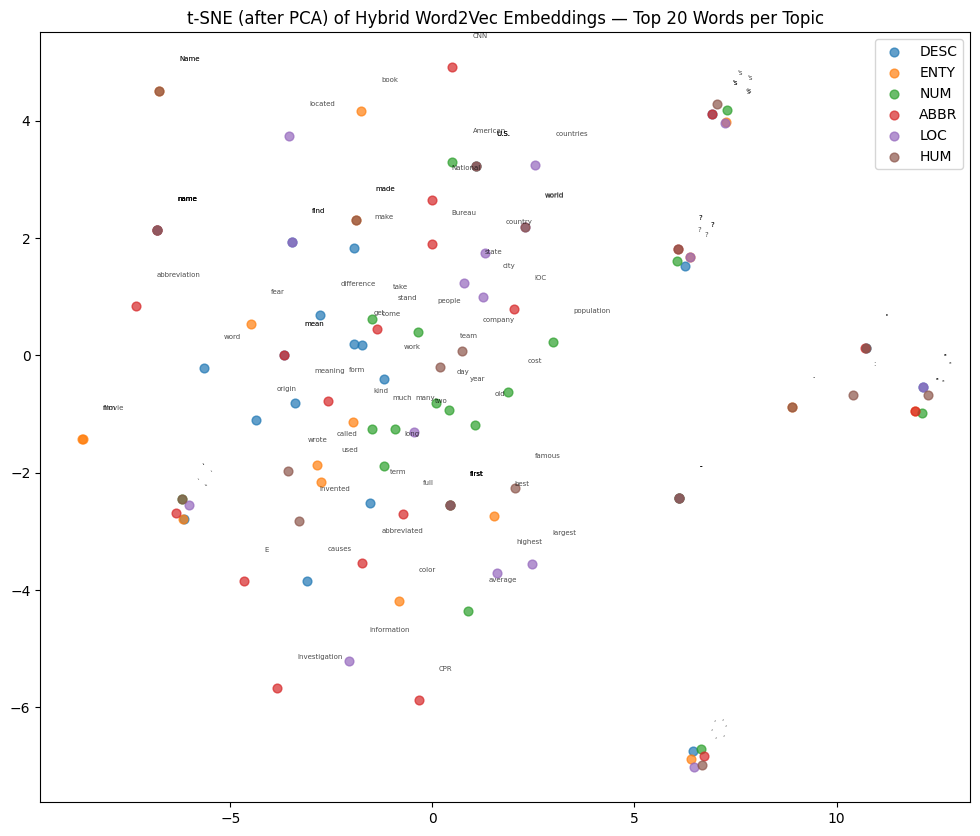

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def get_top_words_by_topic(dataset, n=20):
    topic_words = {}
    for ex in dataset:
        filtered = [w for w in ex.text if w.lower() not in stop_words]
        topic_words.setdefault(ex.label, []).extend(filtered)
    return {lbl: [w for w, _ in Counter(ws).most_common(n)] for lbl, ws in topic_words.items()}

top_words = get_top_words_by_topic(train_data, n=20)

vectors, labels, words_all = [], [], []
for label, words in top_words.items():
    for w in words:
        if w.lower() in stop_words: #for the visualization, we skip common stop words
            continue
        if w in w2v_google.key_to_index:
            vectors.append(w2v_google[w])
            labels.append(label)
            words_all.append(w)
        elif w in w2v_local.wv.key_to_index:
            vectors.append(w2v_local.wv[w])
            labels.append(label)
            words_all.append(w)

vectors = np.array(vectors)

# Step 1: PCA to 50 dimensions (for faster t-SNE)
n_samples = vectors.shape[0]
n_features = vectors.shape[1]
n_pca = min(50, n_samples, n_features)
print("Running PCA -> 50D...")
vectors_pca = PCA(n_components=n_pca, random_state=42).fit_transform(vectors)

# Step 2: t-SNE to 2D
print("Running t-SNE -> 2D (this may take a few minutes)...")
reduced = TSNE(n_components=2, random_state=42).fit_transform(vectors_pca)

# Step 3: Plot colored dots + labels
plt.figure(figsize=(12, 10))
unique_labels = list(set(labels))
colors = plt.cm.get_cmap('tab10', len(unique_labels))

for lbl in unique_labels:
    idx = [i for i,l in enumerate(labels) if l == lbl]
    plt.scatter(reduced[idx, 0], reduced[idx, 1], label=lbl, alpha=0.7, s=40)

# Add text labels for each point
for i, word in enumerate(words_all):
    plt.text(reduced[i, 0] + 0.5, reduced[i, 1] + 0.5, word, fontsize=5, alpha=0.7)

plt.title("t-SNE (after PCA) of Hybrid Word2Vec Embeddings — Top 20 Words per Topic")
plt.legend()
plt.show()

# Part 2. Model Training & Evaluation - RNN

## Simple RNN Model Design


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):
        """
        Simple RNN text classifier with training loop.

        Args:
            embedding_matrix (Tensor): Pretrained embeddings.
            hidden_dim (int): RNN hidden size.
            output_dim (int): Number of output classes.
            lr (float): Learning rate.
            dropout (float): Dropout probability.
            regularization (str): "dropout", "layernorm", "both", or "none".
            optimizer_type (str): "adam", "sgd", or "rmsprop".
            criterion_type (str): "crossentropy", "nll", or "mse".
            weight_decay (float): L2 regularization coefficient.
            device (torch.device): CPU or CUDA device.
        """
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        vocab_size, embedding_dim = embedding_matrix.shape

        # Making pretrained word embeddings from part 1 trainable parameters
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )

        # Using torch library's simple RNN
        self.rnn = nn.RNN(
            input_size = embedding_dim,
            hidden_size = hidden_dim,
            bidirectional = False,
            batch_first = True
        )

        # Regularization
        self.regularization = regularization.lower()
        self.dropout_layer = nn.Dropout(dropout) if self.regularization in ["dropout", "both"] else nn.Identity()
        self.layernorm_layer = nn.LayerNorm(hidden_dim) if self.regularization in ["layernorm", "both"] else nn.Identity()


        # Criterion
        self.criterion = self._init_criterion(criterion_type)

        # Optimizer
        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        # Fully connected layer, input size is hidden_dim
        self.fc = nn.Linear(hidden_dim, output_dim)

        # Move to device
        self.to(self.device)

    def _init_criterion(self, criterion_type):
        ct = criterion_type.lower()
        if ct == "crossentropy":
            return nn.CrossEntropyLoss()
        elif ct == "nll":
            return nn.NLLLoss()
        elif ct == "mse":
            return nn.MSELoss()
        else:
            raise ValueError(f"Unsupported criterion: {criterion_type}")

    def _init_optimizer(self, optimizer_type, lr, weight_decay):
        ot = optimizer_type.lower()
        if ot == "adam":
            return torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        elif ot == "sgd":
            return torch.optim.SGD(self.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        elif ot == "rmsprop":
            return torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_type}")

    def forward(self, text):
        embedded = self.embedding(text)
        outputs, hidden = self.rnn(embedded)

        # Using final hidden state as sentence representation
        sentence_rep = hidden[-1, :, :]


        # Apply regularization based on the selected type
        if self.regularization == "dropout":
            sentence_rep = self.dropout_layer(sentence_rep)
        elif self.regularization == "layernorm":
            sentence_rep = self.layernorm_layer(sentence_rep)
        elif self.regularization == "both":
            sentence_rep = self.layernorm_layer(sentence_rep)
            sentence_rep = self.dropout_layer(sentence_rep)


        logits = self.fc(sentence_rep)
        return logits

    # Helper methods for training and evaluating
    def accuracy(self, preds, y):
        max_preds = preds.argmax(dim=1, keepdim=True)
        correct = max_preds.squeeze(1).eq(y)
        return correct.sum().float() / y.shape[0]

    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            # Ensure text and labels have the same batch size
            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]


            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())


            if train:
                loss.backward()
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)

    # Training loop
    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        """
        Trains and evaluates the model for given epochs.

        Args:
            train_iterator: Data iterator for training.
            valid_iterator: Data iterator for validation.
            epochs (int): Number of epochs.
            early_stopping (int): Stop if val loss doesn’t improve after N epochs.
        """
        best_val_acc = float("-inf")
        patience = 0

        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        break

## Model Init and Training

### Config 1: hidden_dim=128
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = dropout (p=0.2), L2 regularisation (weight decay=0.00001)

In [ ]:
model1 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model1.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
test_loss, test_acc = model1.run_epoch(test_iterator, train=False)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")


Epoch 01: Train Loss: 1.542, Train Acc: 34.27% | Val Loss: 1.259, Val Acc: 50.43%
Epoch 02: Train Loss: 1.057, Train Acc: 62.08% | Val Loss: 0.926, Val Acc: 66.15%
Epoch 03: Train Loss: 0.632, Train Acc: 81.41% | Val Loss: 0.933, Val Acc: 68.49%
Epoch 04: Train Loss: 0.677, Train Acc: 77.81% | Val Loss: 0.797, Val Acc: 74.74%
Epoch 05: Train Loss: 0.372, Train Acc: 91.50% | Val Loss: 0.639, Val Acc: 79.95%
Epoch 06: Train Loss: 0.241, Train Acc: 95.18% | Val Loss: 0.693, Val Acc: 79.51%
Epoch 07: Train Loss: 0.247, Train Acc: 93.91% | Val Loss: 0.824, Val Acc: 73.96%
Epoch 08: Train Loss: 0.245, Train Acc: 94.52% | Val Loss: 0.651, Val Acc: 80.30%
Epoch 09: Train Loss: 0.151, Train Acc: 97.23% | Val Loss: 0.581, Val Acc: 82.90%
Epoch 10: Train Loss: 0.196, Train Acc: 95.49% | Val Loss: 0.834, Val Acc: 74.57%
Epoch 11: Train Loss: 0.181, Train Acc: 96.96% | Val Loss: 0.673, Val Acc: 80.56%
Epoch 12: Train Loss: 0.191, Train Acc: 95.46% | Val Loss: 1.447, Val Acc: 57.99%
Epoch 13: Train 

### Config 2: hidden_dim=256
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 256
* regularisation technique(s) = dropout (p=0.2), L2 regularisation (weight decay=0.00001)

In [14]:
model2 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=256,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model2.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
test_loss, test_acc = model2.run_epoch(test_iterator, train=False)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.419, Train Acc: 40.36% | Val Loss: 1.209, Val Acc: 52.00%
Epoch 02: Train Loss: 1.178, Train Acc: 54.46% | Val Loss: 1.013, Val Acc: 58.59%
Epoch 03: Train Loss: 0.784, Train Acc: 73.61% | Val Loss: 0.775, Val Acc: 70.92%
Epoch 04: Train Loss: 1.173, Train Acc: 57.22% | Val Loss: 0.977, Val Acc: 62.41%
Epoch 05: Train Loss: 0.646, Train Acc: 79.38% | Val Loss: 0.759, Val Acc: 72.05%
Epoch 06: Train Loss: 0.455, Train Acc: 86.68% | Val Loss: 0.685, Val Acc: 77.95%
Epoch 07: Train Loss: 0.357, Train Acc: 90.25% | Val Loss: 0.589, Val Acc: 81.86%
Epoch 08: Train Loss: 0.230, Train Acc: 94.53% | Val Loss: 0.701, Val Acc: 78.30%
Epoch 09: Train Loss: 0.296, Train Acc: 92.07% | Val Loss: 0.619, Val Acc: 80.64%
Epoch 10: Train Loss: 0.203, Train Acc: 95.06% | Val Loss: 0.593, Val Acc: 80.38%
Epoch 11: Train Loss: 0.139, Train Acc: 96.93% | Val Loss: 0.582, Val Acc: 80.99%
Epoch 12: Train Loss: 0.188, Train Acc: 94.88% | Val Loss: 0.776, Val Acc: 75.61%
Early stopping t

### Config 3: hidden_dim=64
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = dropout (p=0.2), L2 regularisation (weight decay=0.00001)

In [22]:
model3 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model3.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
test_loss, test_acc = model3.run_epoch(test_iterator, train=False)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.171, Train Acc: 67.31% | Val Loss: 1.028, Val Acc: 64.58%
Epoch 02: Train Loss: 0.439, Train Acc: 96.40% | Val Loss: 0.783, Val Acc: 79.51%
Epoch 03: Train Loss: 0.285, Train Acc: 98.17% | Val Loss: 0.690, Val Acc: 77.17%
Epoch 04: Train Loss: 0.223, Train Acc: 98.41% | Val Loss: 0.671, Val Acc: 79.17%
Epoch 05: Train Loss: 0.200, Train Acc: 98.53% | Val Loss: 1.027, Val Acc: 71.88%
Epoch 06: Train Loss: 0.226, Train Acc: 97.79% | Val Loss: 0.781, Val Acc: 79.34%
Epoch 07: Train Loss: 0.198, Train Acc: 97.98% | Val Loss: 0.829, Val Acc: 78.21%
Early stopping triggered at epoch 7.

Testing model on test data...
Test Loss: 0.9178 | Test Accuracy: 77.88%


### Config 4: no regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = none

In [21]:
model4 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0,
    regularization="none",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=0
)

# Train and evaluate
model4.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
test_loss, test_acc = model4.run_epoch(test_iterator, train=False)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

Epoch 01: Train Loss: 0.737, Train Acc: 81.72% | Val Loss: 0.771, Val Acc: 77.60%
Epoch 02: Train Loss: 0.152, Train Acc: 98.69% | Val Loss: 0.698, Val Acc: 78.91%
Epoch 03: Train Loss: 0.087, Train Acc: 99.77% | Val Loss: 0.665, Val Acc: 81.51%
Epoch 04: Train Loss: 0.065, Train Acc: 99.91% | Val Loss: 0.729, Val Acc: 80.30%
Epoch 05: Train Loss: 0.050, Train Acc: 99.98% | Val Loss: 0.634, Val Acc: 80.73%
Epoch 06: Train Loss: 0.042, Train Acc: 99.98% | Val Loss: 0.723, Val Acc: 80.21%
Epoch 07: Train Loss: 0.077, Train Acc: 98.87% | Val Loss: 0.857, Val Acc: 76.56%
Epoch 08: Train Loss: 0.133, Train Acc: 97.19% | Val Loss: 0.742, Val Acc: 80.90%
Early stopping triggered at epoch 8.

Testing model on test data...
Test Loss: 1.5203 | Test Accuracy: 66.51%


# Part 2 Question 2. RNN


## 2a) Final configuration of best model

 According to first portion of Part 2, the best model has the following configurations:  
Config 4  
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = none  

We work off these settings and experiment with the regularisation techniques in an attempt to obtain a model that performs even better on the test set based on **accuracy**



## 2b) Comparing accuracy of different regularisation techniques

### Config 5: Only regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = L2 Regularisation (weight decay = 0.00001)

In [ ]:
model5 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0,
    regularization="none",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model5.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model5_test_loss, model5_test_acc = model5.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model5_test_loss:.4f} | Test Accuracy: {model5_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.524, Train Acc: 30.90% | Val Loss: 1.280, Val Acc: 40.62%
Epoch 02: Train Loss: 1.532, Train Acc: 32.97% | Val Loss: 1.551, Val Acc: 36.72%
Epoch 03: Train Loss: 1.173, Train Acc: 58.17% | Val Loss: 1.026, Val Acc: 62.50%
Epoch 04: Train Loss: 0.848, Train Acc: 73.90% | Val Loss: 0.972, Val Acc: 67.53%
Epoch 05: Train Loss: 0.610, Train Acc: 83.90% | Val Loss: 0.877, Val Acc: 69.62%
Epoch 06: Train Loss: 0.410, Train Acc: 92.11% | Val Loss: 0.778, Val Acc: 74.48%
Epoch 07: Train Loss: 0.328, Train Acc: 93.65% | Val Loss: 0.661, Val Acc: 80.12%
Epoch 08: Train Loss: 0.470, Train Acc: 88.47% | Val Loss: 1.110, Val Acc: 61.63%
Epoch 09: Train Loss: 0.417, Train Acc: 89.64% | Val Loss: 0.840, Val Acc: 73.61%
Epoch 10: Train Loss: 0.270, Train Acc: 94.51% | Val Loss: 0.744, Val Acc: 78.47%
Epoch 11: Train Loss: 0.196, Train Acc: 96.71% | Val Loss: 0.692, Val Acc: 77.95%
Epoch 12: Train Loss: 0.227, Train Acc: 94.69% | Val Loss: 0.993, Val Acc: 70.14%
Early stopping t

### Config 6: Stronger regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = L2 Regularisation (weight decay = 0.0001)

In [ ]:
model6 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0,
    regularization="none",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-4
)

# Train and evaluate
model6.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model6_test_loss, model6_test_acc = model6.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model6_test_loss:.4f} | Test Accuracy: {model6_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.501, Train Acc: 35.83% | Val Loss: 1.171, Val Acc: 50.78%
Epoch 02: Train Loss: 0.994, Train Acc: 63.96% | Val Loss: 1.066, Val Acc: 62.07%
Epoch 03: Train Loss: 0.724, Train Acc: 79.36% | Val Loss: 0.826, Val Acc: 71.44%
Epoch 04: Train Loss: 0.540, Train Acc: 85.72% | Val Loss: 0.754, Val Acc: 76.48%
Epoch 05: Train Loss: 0.809, Train Acc: 73.94% | Val Loss: 1.360, Val Acc: 55.21%
Epoch 06: Train Loss: 1.055, Train Acc: 63.47% | Val Loss: 1.072, Val Acc: 57.20%
Epoch 07: Train Loss: 0.926, Train Acc: 66.16% | Val Loss: 1.144, Val Acc: 54.69%
Epoch 08: Train Loss: 0.684, Train Acc: 77.90% | Val Loss: 0.801, Val Acc: 71.53%
Epoch 09: Train Loss: 0.520, Train Acc: 86.07% | Val Loss: 0.879, Val Acc: 71.70%
Early stopping triggered at epoch 9.

Testing model on test data...
Test Loss: 1.9778 | Test Accuracy: 32.95%


### Config 7: Dropout and L2 Regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Dropout (p=0.2), L2 Regularisation (weight decay = 0.00001)

In [ ]:
model7 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model7.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model7_test_loss, model7_test_acc = model7.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model7_test_loss:.4f} | Test Accuracy: {model7_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.577, Train Acc: 31.30% | Val Loss: 1.552, Val Acc: 35.24%
Epoch 02: Train Loss: 1.294, Train Acc: 48.98% | Val Loss: 1.166, Val Acc: 51.65%
Epoch 03: Train Loss: 0.880, Train Acc: 70.55% | Val Loss: 0.824, Val Acc: 72.57%
Epoch 04: Train Loss: 0.657, Train Acc: 81.03% | Val Loss: 0.744, Val Acc: 73.00%
Epoch 05: Train Loss: 0.420, Train Acc: 90.71% | Val Loss: 0.769, Val Acc: 75.87%
Epoch 06: Train Loss: 0.305, Train Acc: 94.05% | Val Loss: 0.720, Val Acc: 77.78%
Epoch 07: Train Loss: 0.300, Train Acc: 93.11% | Val Loss: 0.985, Val Acc: 67.53%
Epoch 08: Train Loss: 0.286, Train Acc: 94.33% | Val Loss: 0.893, Val Acc: 73.00%
Epoch 09: Train Loss: 0.200, Train Acc: 96.87% | Val Loss: 0.720, Val Acc: 80.56%
Epoch 10: Train Loss: 0.176, Train Acc: 97.10% | Val Loss: 0.808, Val Acc: 75.35%
Epoch 11: Train Loss: 0.214, Train Acc: 96.02% | Val Loss: 0.800, Val Acc: 77.52%
Epoch 12: Train Loss: 0.109, Train Acc: 99.07% | Val Loss: 0.720, Val Acc: 80.21%
Epoch 13: Train 

### Config 8: Weaker Dropout and L2 Regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Dropout (p=0.1), L2 Regularisation (weight decay = 0.00001)

In [ ]:
model8 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.1,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model8.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model8_test_loss, model8_test_acc = model8.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model8_test_loss:.4f} | Test Accuracy: {model8_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.492, Train Acc: 36.88% | Val Loss: 1.245, Val Acc: 48.87%
Epoch 02: Train Loss: 0.961, Train Acc: 68.16% | Val Loss: 0.944, Val Acc: 67.62%
Epoch 03: Train Loss: 0.675, Train Acc: 80.68% | Val Loss: 0.669, Val Acc: 80.38%
Epoch 04: Train Loss: 0.466, Train Acc: 88.37% | Val Loss: 1.014, Val Acc: 68.23%
Epoch 05: Train Loss: 0.522, Train Acc: 85.83% | Val Loss: 0.971, Val Acc: 68.49%
Epoch 06: Train Loss: 0.402, Train Acc: 90.40% | Val Loss: 0.615, Val Acc: 81.60%
Epoch 07: Train Loss: 0.326, Train Acc: 92.77% | Val Loss: 0.684, Val Acc: 80.03%
Epoch 08: Train Loss: 0.205, Train Acc: 96.73% | Val Loss: 0.500, Val Acc: 85.24%
Epoch 09: Train Loss: 0.189, Train Acc: 96.58% | Val Loss: 0.655, Val Acc: 82.12%
Epoch 10: Train Loss: 0.247, Train Acc: 94.79% | Val Loss: 0.646, Val Acc: 81.08%
Epoch 11: Train Loss: 0.204, Train Acc: 95.88% | Val Loss: 0.748, Val Acc: 78.65%
Epoch 12: Train Loss: 0.170, Train Acc: 97.09% | Val Loss: 0.660, Val Acc: 81.60%
Epoch 13: Train 

### Config 9: Layernorm and L2 Regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Layernorm , L2 Regularisation (weight decay = 0.00001)

In [ ]:
model9 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0,
    regularization="layernorm",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model9.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model9_test_loss, model9_test_acc = model9.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model9_test_loss:.4f} | Test Accuracy: {model9_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.560, Train Acc: 33.94% | Val Loss: 1.359, Val Acc: 50.00%
Epoch 02: Train Loss: 0.886, Train Acc: 67.81% | Val Loss: 1.090, Val Acc: 56.51%
Epoch 03: Train Loss: 0.570, Train Acc: 82.52% | Val Loss: 0.840, Val Acc: 69.62%
Epoch 04: Train Loss: 0.232, Train Acc: 94.93% | Val Loss: 0.802, Val Acc: 76.04%
Epoch 05: Train Loss: 0.213, Train Acc: 94.45% | Val Loss: 1.210, Val Acc: 56.68%
Epoch 06: Train Loss: 0.241, Train Acc: 94.52% | Val Loss: 0.912, Val Acc: 71.18%
Epoch 07: Train Loss: 0.121, Train Acc: 97.37% | Val Loss: 1.016, Val Acc: 69.97%
Epoch 08: Train Loss: 0.051, Train Acc: 99.46% | Val Loss: 0.924, Val Acc: 73.26%
Epoch 09: Train Loss: 0.028, Train Acc: 99.80% | Val Loss: 0.962, Val Acc: 72.92%
Early stopping triggered at epoch 9.

Testing model on test data...
Test Loss: 1.2604 | Test Accuracy: 44.55%


### Config 10: Layernorm and Stronger L2 Regularisation
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Layernorm , L2 Regularisation (weight decay = 0.0001)

In [ ]:
model10 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0,
    regularization="layernorm",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-4
)

# Train and evaluate
model10.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model10_test_loss, model10_test_acc = model10.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model10_test_loss:.4f} | Test Accuracy: {model10_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.598, Train Acc: 31.01% | Val Loss: 1.356, Val Acc: 47.31%
Epoch 02: Train Loss: 1.130, Train Acc: 57.55% | Val Loss: 1.037, Val Acc: 59.03%
Epoch 03: Train Loss: 0.589, Train Acc: 82.36% | Val Loss: 0.888, Val Acc: 65.97%
Epoch 04: Train Loss: 0.328, Train Acc: 91.04% | Val Loss: 0.785, Val Acc: 71.79%
Epoch 05: Train Loss: 0.209, Train Acc: 94.44% | Val Loss: 0.788, Val Acc: 73.00%
Epoch 06: Train Loss: 0.134, Train Acc: 96.99% | Val Loss: 0.739, Val Acc: 73.35%
Epoch 07: Train Loss: 0.097, Train Acc: 98.03% | Val Loss: 0.912, Val Acc: 70.83%
Epoch 08: Train Loss: 0.071, Train Acc: 98.85% | Val Loss: 0.915, Val Acc: 72.22%
Epoch 09: Train Loss: 0.064, Train Acc: 99.04% | Val Loss: 0.991, Val Acc: 72.48%
Epoch 10: Train Loss: 0.133, Train Acc: 96.56% | Val Loss: 0.910, Val Acc: 73.18%
Epoch 11: Train Loss: 0.036, Train Acc: 99.62% | Val Loss: 0.916, Val Acc: 75.35%
Epoch 12: Train Loss: 0.020, Train Acc: 99.86% | Val Loss: 0.965, Val Acc: 73.78%
Epoch 13: Train 

### Config 10: Layernorm and dropout
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Dropout = 0.2, Layernorm , L2 Regularisation (weight decay = 0.0001)

In [ ]:
model11 = RNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="both",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)

# Train and evaluate
model11.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model11_test_loss, model11_test_acc = model11.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model11_test_loss:.4f} | Test Accuracy: {model11_test_acc*100:.2f}%")

Epoch 01: Train Loss: 1.648, Train Acc: 28.05% | Val Loss: 1.505, Val Acc: 37.24%
Epoch 02: Train Loss: 1.043, Train Acc: 62.88% | Val Loss: 0.908, Val Acc: 66.58%
Epoch 03: Train Loss: 0.607, Train Acc: 82.56% | Val Loss: 0.741, Val Acc: 75.52%
Epoch 04: Train Loss: 0.308, Train Acc: 94.74% | Val Loss: 0.755, Val Acc: 74.22%
Epoch 05: Train Loss: 0.185, Train Acc: 97.77% | Val Loss: 0.640, Val Acc: 80.56%
Epoch 06: Train Loss: 0.150, Train Acc: 98.16% | Val Loss: 0.720, Val Acc: 77.78%
Epoch 07: Train Loss: 0.100, Train Acc: 99.02% | Val Loss: 0.680, Val Acc: 79.25%
Epoch 08: Train Loss: 0.079, Train Acc: 99.20% | Val Loss: 0.698, Val Acc: 75.95%
Epoch 09: Train Loss: 0.060, Train Acc: 99.62% | Val Loss: 0.726, Val Acc: 77.78%
Epoch 10: Train Loss: 0.047, Train Acc: 99.82% | Val Loss: 0.755, Val Acc: 77.00%
Early stopping triggered at epoch 10.

Testing model on test data...
Test Loss: 0.9807 | Test Accuracy: 63.70%


### Table of Comparison of Accuracy
| Config | Regularisation Used| Dropout | Weight Decay | Test Accuracy |
|--------|---------------|---------|--------------|---------------|
| Config 4 | none  | 0 | 0 | 72.79% |
| Config 5 | L2   | 0 | 1e-5 | 70.09% |
| Config 6 | L2  | 0 | 1e-4 | 32.95% |
| Config 7 | Dropout + L2  | 0.2 | 1e-5 |80.11% |
| Config 8 | Dropout + L2  | 0.1 | 1e-5 | 75.44% |
| Config 9 | Layernorm + L2  | 0 | 1e-5 | 44.55% |
| Config 10 | Layernorm + L2  | 0 | 1e-4 | 63.70% |

Comparable accuracies between the model with no regularisation and those with. The model that performs the best on the test data is config 7 with dropout = 0.2 and L2 Regularisation with weight decay set as 1e-5.

**However**, we can also see that based on the training and validation accuracy differences, the models using the simple RNNClassifier are overfitting a lot as training accuracy tends to reach close to 100% while validation and test accuracy hovers 20-30% lower than that. Thus, in the next portion we plot the train vs val loss and accuracy curves. Additionally, we perform further tuning to minimize overfitting of the model using Config 7 as a starting point for tuning.

## 2c) Training loss and accuracy curves
For the best configuration and regularization strategy in your experiments, plot the training
loss curve and validation accuracy curve during training with x-axis being the number of
training epochs. Discuss what the curves inform about the training dynamics

### Defining RNNClassifier and helper function for plotting train vs val loss and accuracy

In [ ]:
# Inherits RNNClassifier to modify fit to store histroy of training for plotting
class RNNClassifierPlotter(RNNClassifier):

    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        """
        Trains and evaluates the model for given epochs.

        Args:
            train_iterator: Data iterator for training.
            valid_iterator: Data iterator for validation.
            epochs (int): Number of epochs.
            early_stopping (int): Stop if val loss doesn’t improve after N epochs.
        """
        best_val_acc = float("-inf")
        patience = 0

        history = {
          'train_loss': [],
          'train_acc': [],
          'val_loss': [],
          'val_acc': [],
          'epochs': 0
      }

        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)

            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

In [ ]:
# function for plotting
import matplotlib.pyplot as plt
def plot_acc_loss_curves(history):
  # get epochs
  num_epochs = history['epochs']
  epochs_list = range(1, num_epochs + 1)
  # Plot 1: Loss Curve
  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, history['train_loss'], label='Training Loss', marker='o')
  plt.plot(epochs_list, history['val_loss'], label='Validation Loss', marker='x')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Plot 2: Accuracy Curve
  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, [acc * 100 for acc in history['train_acc']], label='Training Accuracy', marker='o')
  plt.plot(epochs_list, [acc * 100 for acc in history['val_acc']], label='Validation Accuracy', marker='x')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()
  plt.grid(True)
  plt.show()

Epoch 01: Train Loss: 1.570, Train Acc: 32.87% | Val Loss: 1.543, Val Acc: 34.81%
Epoch 02: Train Loss: 1.127, Train Acc: 57.14% | Val Loss: 1.070, Val Acc: 63.80%
Epoch 03: Train Loss: 0.769, Train Acc: 76.90% | Val Loss: 0.801, Val Acc: 74.65%
Epoch 04: Train Loss: 0.471, Train Acc: 88.26% | Val Loss: 0.731, Val Acc: 78.82%
Epoch 05: Train Loss: 0.343, Train Acc: 92.38% | Val Loss: 0.557, Val Acc: 83.68%
Epoch 06: Train Loss: 0.236, Train Acc: 95.59% | Val Loss: 0.535, Val Acc: 84.03%
Epoch 07: Train Loss: 0.225, Train Acc: 95.29% | Val Loss: 0.716, Val Acc: 79.08%
Epoch 08: Train Loss: 0.310, Train Acc: 91.99% | Val Loss: 0.558, Val Acc: 83.77%
Epoch 09: Train Loss: 0.263, Train Acc: 93.91% | Val Loss: 0.576, Val Acc: 82.99%
Epoch 10: Train Loss: 0.166, Train Acc: 96.78% | Val Loss: 0.517, Val Acc: 85.07%
Epoch 11: Train Loss: 0.133, Train Acc: 97.36% | Val Loss: 0.536, Val Acc: 82.03%
Epoch 12: Train Loss: 0.134, Train Acc: 96.96% | Val Loss: 0.766, Val Acc: 74.65%
Epoch 13: Train 

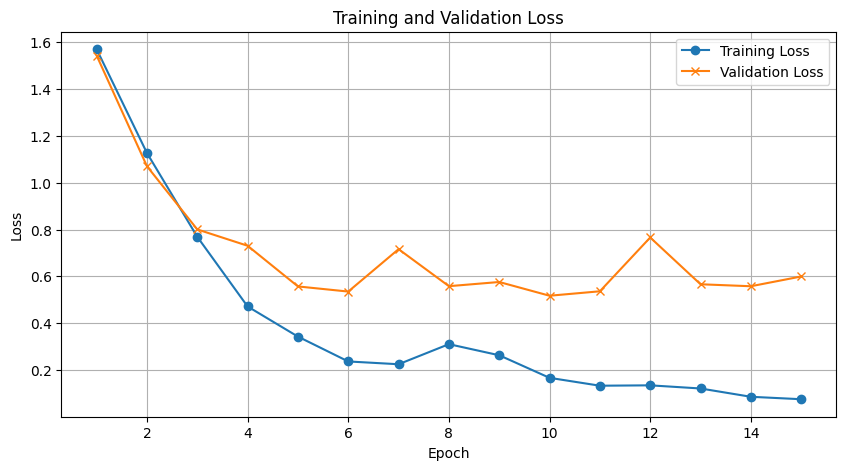

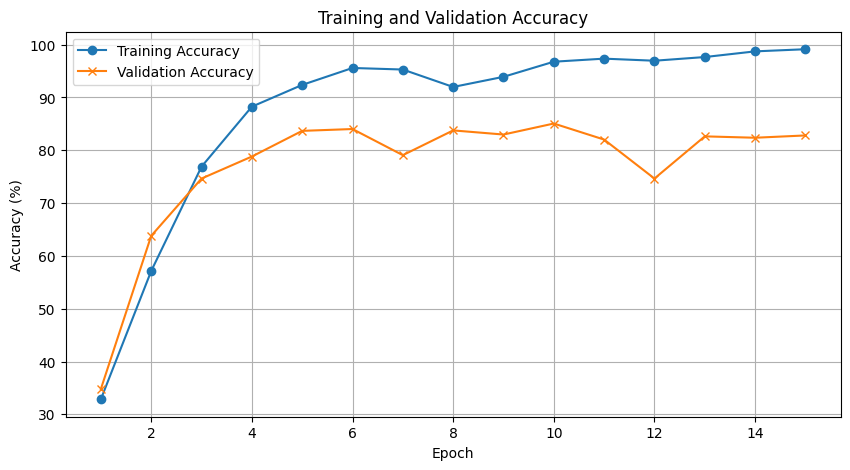

In [ ]:
# Reinitialise config 7 model to plot loss and accuracy curves
model7_plot = RNNClassifierPlotter(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)


# Train and evaluate
history7 = model7_plot.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

plot_acc_loss_curves(history7)

Our 'best' configuration from earlier is overfittng by ~20%. Thus, let's continue tuning!

### Setting Freeze = True and reducing hidden dimensions
Overfitting usually occurs when a model is too large for the dataset it is being trained on. Thus we attempt to implement 2 approaches to reduce the number of learnable parameters

1.   Setting Freeze = True so that the model is not learning the entire embedding matrix i.e making it hard for it to memorize unique paths to desired outputs
2.   Reducing hidden dimensions






In [ ]:
# Inherits RNNClassifier to modify fit to store histroy of training for plotting and
# sets freeze = true
class RNNClassifierPlotter2(RNNClassifier):

    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        self.to(self.device)

    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
          'train_loss': [],
          'train_acc': [],
          'val_loss': [],
          'val_acc': [],
          'epochs': 0
        }



        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)
            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

### Config 12: Freeze = True
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 128
* regularisation technique(s) = Dropout = 0.2, Layernorm , L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.545, Train Acc: 33.14% | Val Loss: 1.294, Val Acc: 49.83%
Epoch 02: Train Loss: 1.073, Train Acc: 60.04% | Val Loss: 0.951, Val Acc: 63.28%
Epoch 03: Train Loss: 0.948, Train Acc: 66.87% | Val Loss: 0.956, Val Acc: 62.24%
Epoch 04: Train Loss: 0.786, Train Acc: 72.61% | Val Loss: 0.941, Val Acc: 65.10%
Epoch 05: Train Loss: 0.792, Train Acc: 73.86% | Val Loss: 1.065, Val Acc: 61.98%
Epoch 06: Train Loss: 0.799, Train Acc: 72.71% | Val Loss: 0.791, Val Acc: 74.22%
Epoch 07: Train Loss: 0.799, Train Acc: 74.01% | Val Loss: 0.934, Val Acc: 67.88%
Epoch 08: Train Loss: 0.626, Train Acc: 79.38% | Val Loss: 0.737, Val Acc: 76.39%
Epoch 09: Train Loss: 0.572, Train Acc: 81.06% | Val Loss: 0.710, Val Acc: 74.31%
Epoch 10: Train Loss: 0.565, Train Acc: 80.88% | Val Loss: 0.641, Val Acc: 77.86%
Epoch 11: Train Loss: 0.535, Train Acc: 81.63% | Val Loss: 0.994, Val Acc: 72.05%
Epoch 12: Train Loss: 0.576, Train Acc: 81.11% | Val Loss: 0.704, Val Acc: 78.21%
Epoch 13: Train 

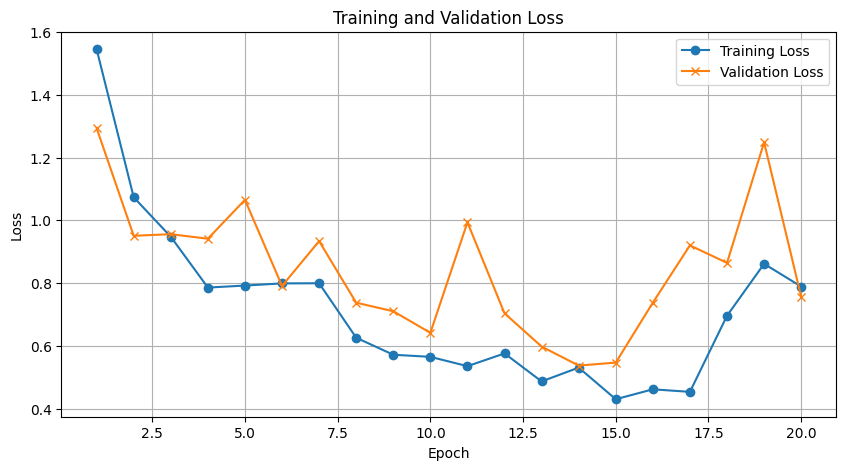

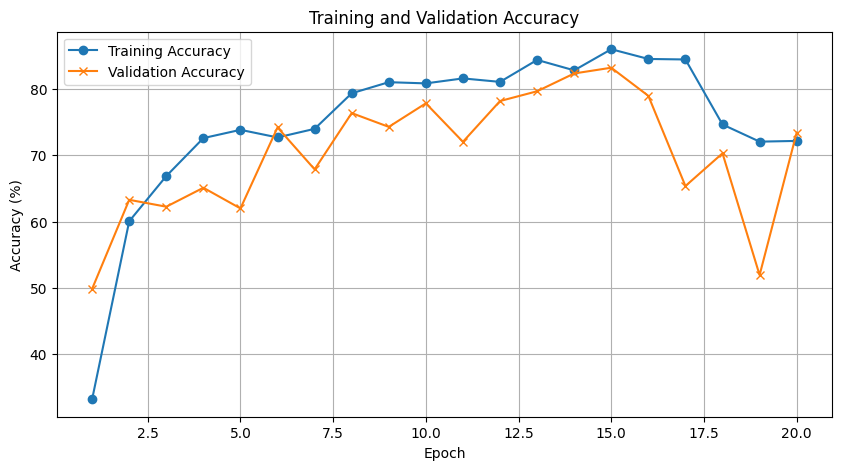

In [ ]:
model12 = RNNClassifierPlotter2(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=128,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history12 = model12.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

plot_acc_loss_curves(history12)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model12_test_loss, model12_test_acc = model12.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model12_test_loss:.4f} | Test Accuracy: {model12_test_acc*100:.2f}%")


Testing model on test data...
Test Loss: 1.2545 | Test Accuracy: 58.43%


### Config 13: Freeze = True
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2, L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.647, Train Acc: 27.55% | Val Loss: 1.594, Val Acc: 33.16%
Epoch 02: Train Loss: 1.353, Train Acc: 45.53% | Val Loss: 1.252, Val Acc: 51.56%
Epoch 03: Train Loss: 1.057, Train Acc: 58.71% | Val Loss: 0.978, Val Acc: 62.07%
Epoch 04: Train Loss: 0.899, Train Acc: 67.45% | Val Loss: 0.937, Val Acc: 64.76%
Epoch 05: Train Loss: 0.921, Train Acc: 67.45% | Val Loss: 0.899, Val Acc: 67.71%
Epoch 06: Train Loss: 0.740, Train Acc: 74.26% | Val Loss: 0.988, Val Acc: 65.89%
Epoch 07: Train Loss: 0.692, Train Acc: 76.41% | Val Loss: 0.865, Val Acc: 69.97%
Epoch 08: Train Loss: 0.633, Train Acc: 79.02% | Val Loss: 0.779, Val Acc: 74.05%
Epoch 09: Train Loss: 0.598, Train Acc: 80.42% | Val Loss: 0.808, Val Acc: 72.05%
Epoch 10: Train Loss: 0.567, Train Acc: 81.50% | Val Loss: 0.807, Val Acc: 74.65%
Epoch 11: Train Loss: 0.620, Train Acc: 80.28% | Val Loss: 0.888, Val Acc: 73.87%
Epoch 12: Train Loss: 0.613, Train Acc: 80.21% | Val Loss: 0.735, Val Acc: 77.60%
Epoch 13: Train 

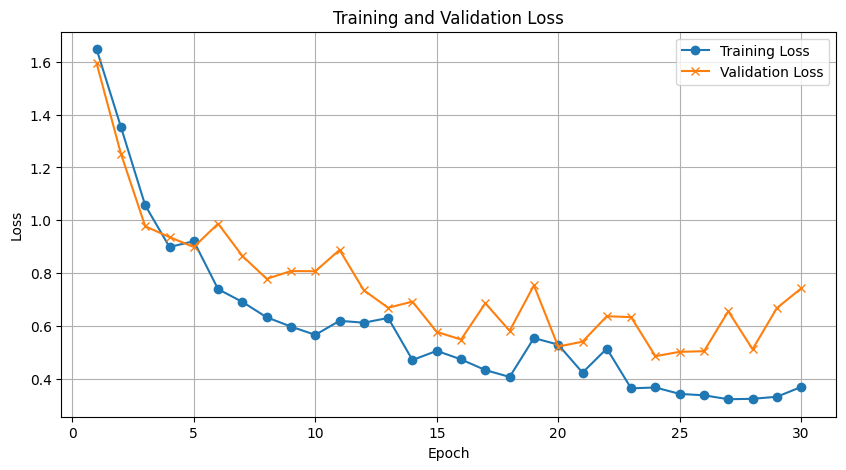

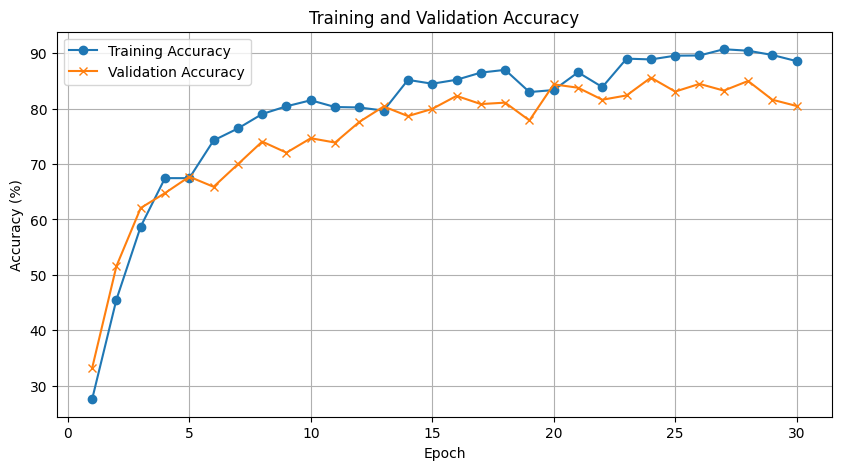

In [ ]:
# reduced dimensions
model13 = RNNClassifierPlotter2(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history13 = model13.fit(train_iterator, valid_iterator, epochs=30, early_stopping=10)

plot_acc_loss_curves(history13)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model13_test_loss, model13_test_acc = model13.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model13_test_loss:.4f} | Test Accuracy: {model13_test_acc*100:.2f}%")


Testing model on test data...
Test Loss: 1.7115 | Test Accuracy: 61.46%


The loss and accuracy curves seem to be erratic, thus we introduce gradient clipping to stabilise the training process


### RNNClassifier with gradient clipping

In [ ]:
# Inherits RNNClassifier to modify fit to store histroy of training for plotting and
# sets freeze = true
class RNNClassifierPlotterGrad(RNNClassifier):

    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        self.to(self.device)


    # run epoch with gradient clipping
    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            # Ensure text and labels have the same batch size
            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]


            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())


            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)
    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
          'train_loss': [],
          'train_acc': [],
          'val_loss': [],
          'val_acc': [],
          'epochs': 0
        }



        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)
            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

### Config 14: Freeze = True and Gradient Clipping
* learning rate = 0.001
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2, L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.698, Train Acc: 22.56% | Val Loss: 1.672, Val Acc: 21.83%
Epoch 02: Train Loss: 1.572, Train Acc: 33.41% | Val Loss: 1.533, Val Acc: 39.54%
Epoch 03: Train Loss: 1.325, Train Acc: 47.69% | Val Loss: 1.238, Val Acc: 53.57%
Epoch 04: Train Loss: 1.063, Train Acc: 59.96% | Val Loss: 0.932, Val Acc: 67.70%
Epoch 05: Train Loss: 0.873, Train Acc: 70.65% | Val Loss: 0.857, Val Acc: 68.87%
Epoch 06: Train Loss: 0.821, Train Acc: 72.23% | Val Loss: 0.807, Val Acc: 72.03%
Epoch 07: Train Loss: 0.708, Train Acc: 77.25% | Val Loss: 0.736, Val Acc: 75.95%
Epoch 08: Train Loss: 0.637, Train Acc: 79.71% | Val Loss: 0.741, Val Acc: 75.20%
Epoch 09: Train Loss: 0.616, Train Acc: 80.41% | Val Loss: 0.672, Val Acc: 79.16%
Epoch 10: Train Loss: 0.588, Train Acc: 80.28% | Val Loss: 0.657, Val Acc: 78.40%
Epoch 11: Train Loss: 0.557, Train Acc: 82.21% | Val Loss: 0.673, Val Acc: 77.11%
Epoch 12: Train Loss: 0.554, Train Acc: 82.21% | Val Loss: 0.759, Val Acc: 76.68%
Epoch 13: Train 

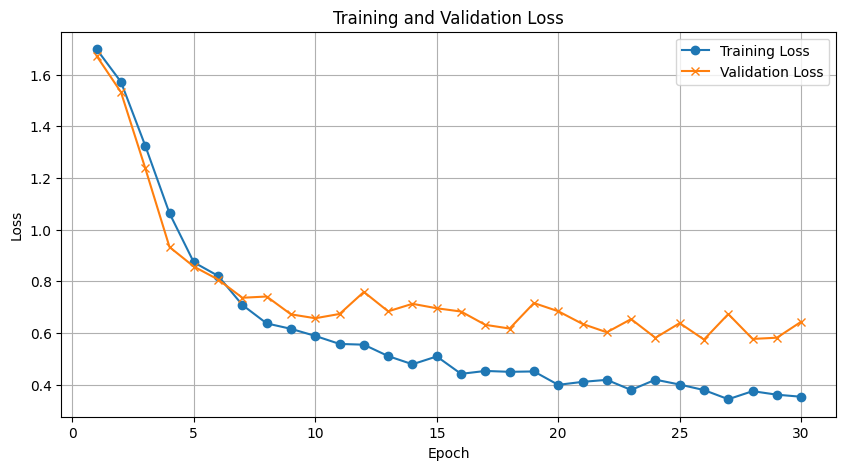

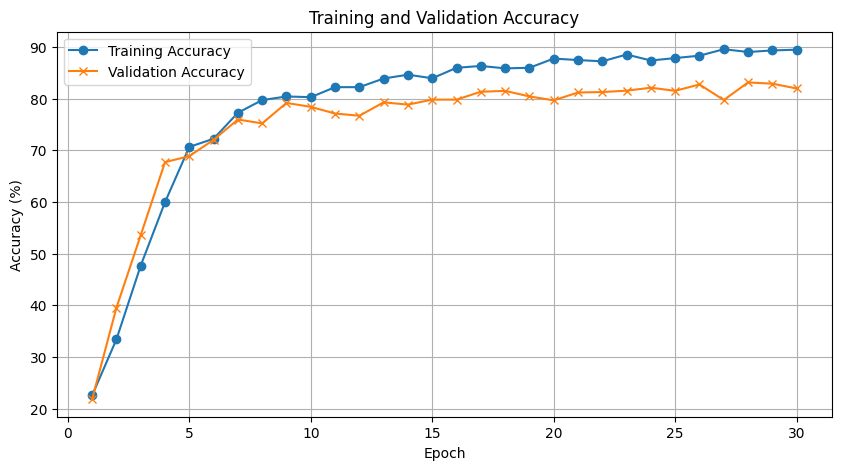

In [ ]:

model14 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=1e-3,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history14 = model14.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

plot_acc_loss_curves(history14)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model14_test_loss, model14_test_acc = model14.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model14_test_loss:.4f} | Test Accuracy: {model14_test_acc*100:.2f}%")


Testing model on test data...
Test Loss: 1.2115 | Test Accuracy: 68.30%


Models learning curves still seem unstable, so we reduce learning rate

### Config 15: Freeze = True and Gradient Clipping
* learning rate = 0.0001
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2 , L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.741, Train Acc: 21.05% | Val Loss: 1.722, Val Acc: 20.14%
Epoch 02: Train Loss: 1.691, Train Acc: 23.38% | Val Loss: 1.685, Val Acc: 21.96%
Epoch 03: Train Loss: 1.663, Train Acc: 24.22% | Val Loss: 1.666, Val Acc: 21.96%
Epoch 04: Train Loss: 1.643, Train Acc: 26.01% | Val Loss: 1.650, Val Acc: 22.83%
Epoch 05: Train Loss: 1.631, Train Acc: 27.59% | Val Loss: 1.640, Val Acc: 24.48%
Epoch 06: Train Loss: 1.613, Train Acc: 28.71% | Val Loss: 1.623, Val Acc: 25.69%
Epoch 07: Train Loss: 1.574, Train Acc: 34.47% | Val Loss: 1.568, Val Acc: 32.81%
Epoch 08: Train Loss: 1.489, Train Acc: 39.52% | Val Loss: 1.456, Val Acc: 41.23%
Epoch 09: Train Loss: 1.397, Train Acc: 44.02% | Val Loss: 1.379, Val Acc: 45.31%
Epoch 10: Train Loss: 1.318, Train Acc: 48.37% | Val Loss: 1.324, Val Acc: 46.70%
Epoch 11: Train Loss: 1.254, Train Acc: 50.57% | Val Loss: 1.273, Val Acc: 49.05%
Epoch 12: Train Loss: 1.191, Train Acc: 53.97% | Val Loss: 1.219, Val Acc: 52.43%
Epoch 13: Train 

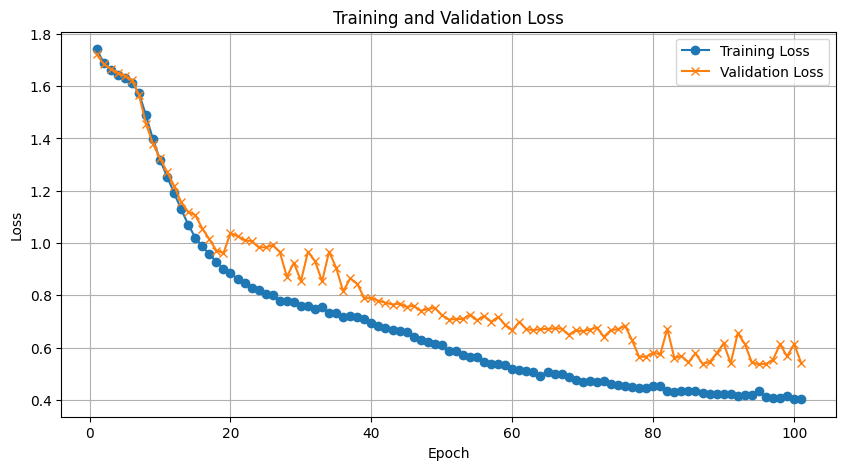

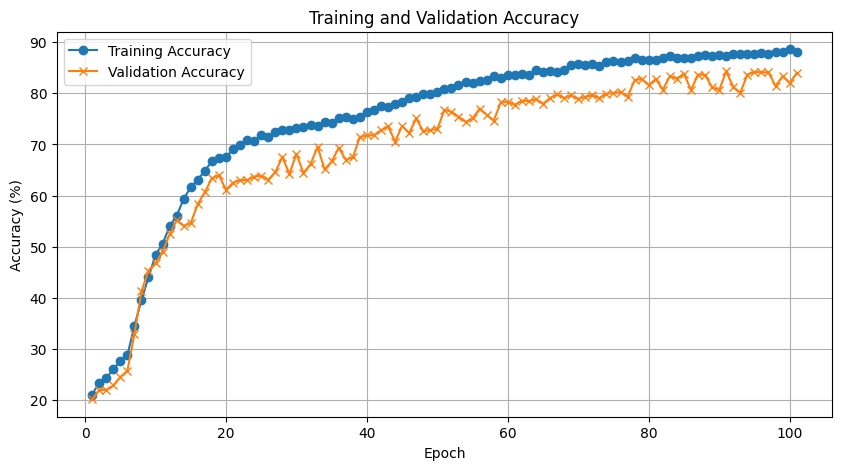

In [ ]:
# decrease learning rate and increase epochs + patience to allow for more confidence before terminating training due to slower learning
# reduced dimensions
model15 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=1e-4,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history15 = model15.fit(train_iterator, valid_iterator, epochs=150, early_stopping=10)

plot_acc_loss_curves(history15)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model15_test_loss, model15_test_acc = model15.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model15_test_loss:.4f} | Test Accuracy: {model15_test_acc*100:.2f}%")



Testing model on test data...
Test Loss: 1.2729 | Test Accuracy: 65.70%


We attempt to further reduce learning rate due to the still erratic curves

### Config 16: Freeze = True and Gradient Clipping
* learning rate = 0.00005
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2 , L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.789, Train Acc: 15.62% | Val Loss: 1.773, Val Acc: 19.01%
Epoch 02: Train Loss: 1.742, Train Acc: 20.60% | Val Loss: 1.743, Val Acc: 22.22%
Epoch 03: Train Loss: 1.713, Train Acc: 22.52% | Val Loss: 1.720, Val Acc: 23.87%
Epoch 04: Train Loss: 1.690, Train Acc: 24.45% | Val Loss: 1.702, Val Acc: 22.66%
Epoch 05: Train Loss: 1.669, Train Acc: 25.77% | Val Loss: 1.685, Val Acc: 23.00%
Epoch 06: Train Loss: 1.663, Train Acc: 25.60% | Val Loss: 1.673, Val Acc: 23.61%
Epoch 07: Train Loss: 1.650, Train Acc: 25.41% | Val Loss: 1.663, Val Acc: 23.70%
Epoch 08: Train Loss: 1.643, Train Acc: 25.62% | Val Loss: 1.657, Val Acc: 24.05%
Epoch 09: Train Loss: 1.635, Train Acc: 25.77% | Val Loss: 1.650, Val Acc: 23.87%
Epoch 10: Train Loss: 1.627, Train Acc: 27.56% | Val Loss: 1.645, Val Acc: 24.05%
Epoch 11: Train Loss: 1.623, Train Acc: 27.98% | Val Loss: 1.639, Val Acc: 24.74%
Epoch 12: Train Loss: 1.612, Train Acc: 29.24% | Val Loss: 1.632, Val Acc: 26.39%
Epoch 13: Train 

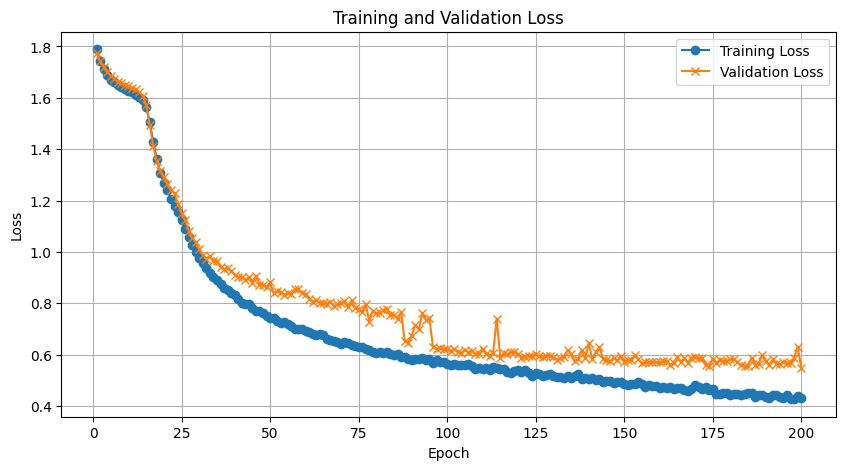

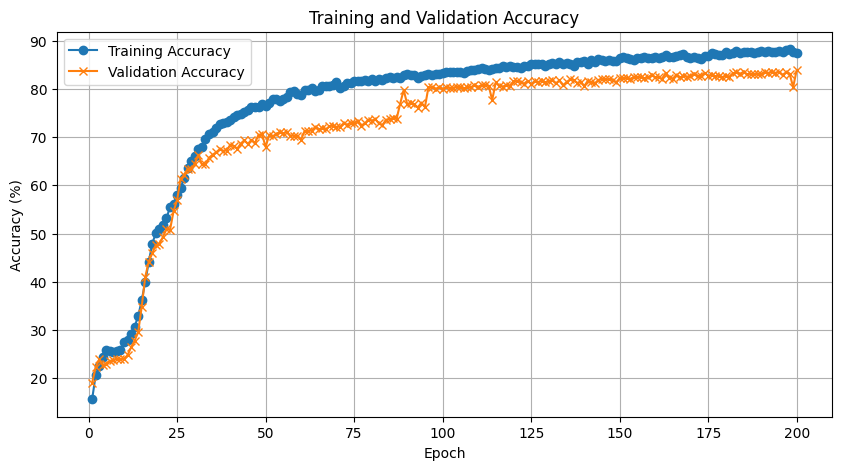

In [ ]:
# model15's learning still seems pretty unstable, we thus reduce learning rate a bit more and increase number of epochs and  early stopping to ensure model learns to completion before stopping
model16 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history16 = model16.fit(train_iterator, valid_iterator, epochs=200, early_stopping=20)

plot_acc_loss_curves(history16)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model16_test_loss, model16_test_acc = model16.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model16_test_loss:.4f} | Test Accuracy: {model16_test_acc*100:.2f}%")



Testing model on test data...
Test Loss: 1.2155 | Test Accuracy: 65.59%


### Config 17: Freeze = True and Gradient Clipping
* learning rate = 0.00005
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2, L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.780, Train Acc: 19.20% | Val Loss: 1.766, Val Acc: 22.48%
Epoch 02: Train Loss: 1.739, Train Acc: 22.16% | Val Loss: 1.739, Val Acc: 22.92%
Epoch 03: Train Loss: 1.710, Train Acc: 23.17% | Val Loss: 1.717, Val Acc: 23.09%
Epoch 04: Train Loss: 1.689, Train Acc: 25.03% | Val Loss: 1.700, Val Acc: 20.66%
Epoch 05: Train Loss: 1.674, Train Acc: 25.28% | Val Loss: 1.685, Val Acc: 21.27%
Epoch 06: Train Loss: 1.659, Train Acc: 25.48% | Val Loss: 1.672, Val Acc: 21.70%
Epoch 07: Train Loss: 1.645, Train Acc: 26.05% | Val Loss: 1.661, Val Acc: 22.31%
Epoch 08: Train Loss: 1.639, Train Acc: 26.72% | Val Loss: 1.650, Val Acc: 22.40%
Epoch 09: Train Loss: 1.627, Train Acc: 27.51% | Val Loss: 1.640, Val Acc: 23.87%
Epoch 10: Train Loss: 1.613, Train Acc: 28.82% | Val Loss: 1.623, Val Acc: 25.69%
Epoch 11: Train Loss: 1.587, Train Acc: 32.29% | Val Loss: 1.590, Val Acc: 28.56%
Epoch 12: Train Loss: 1.531, Train Acc: 38.10% | Val Loss: 1.498, Val Acc: 38.54%
Epoch 13: Train 

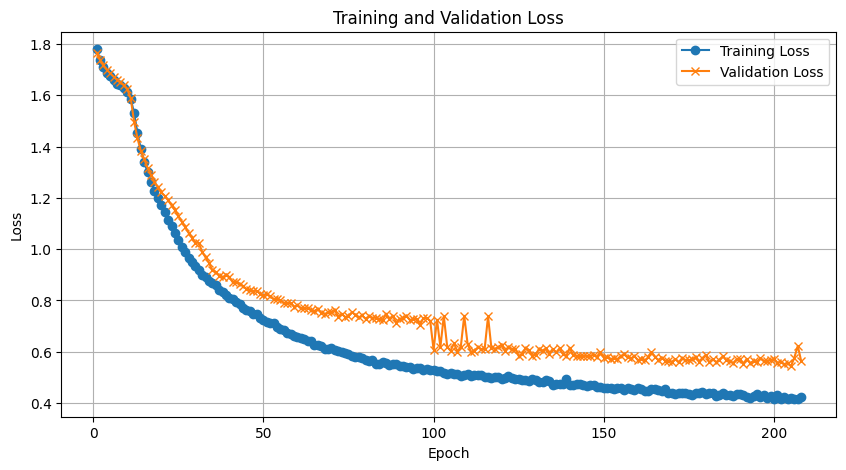

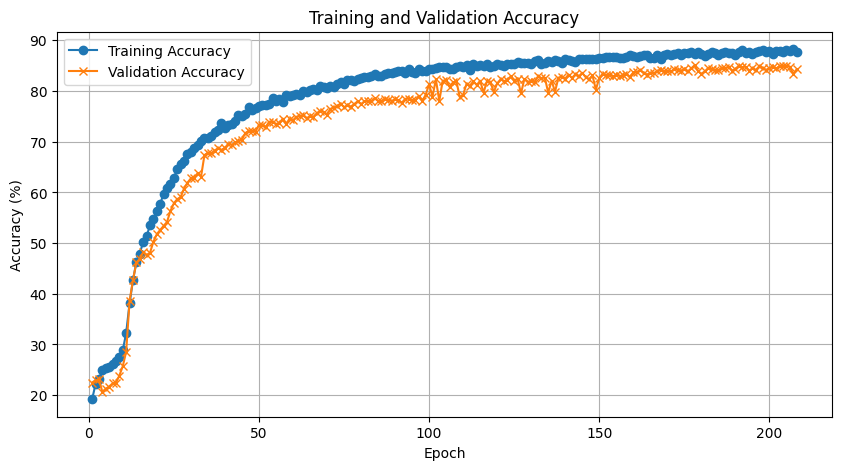

In [ ]:
# model16 showed some potential for further decreases in loss and increases in accuracy, thus we attempt again with the same settings but higher epochs and patience
model17 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history17 = model17.fit(train_iterator, valid_iterator, epochs=300, early_stopping=30)

plot_acc_loss_curves(history17)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model17_test_loss, model17_test_acc = model17.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model17_test_loss:.4f} | Test Accuracy: {model17_test_acc*100:.2f}%")



Testing model on test data...
Test Loss: 0.8228 | Test Accuracy: 72.16%


This gives us all time high on test accuracy but let's try to make some further tweaks just to test if we can push accuracy higher

### Config 18: Freeze = True and Gradient Clipping
* learning rate = 0.00004
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2 , L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.774, Train Acc: 19.54% | Val Loss: 1.760, Val Acc: 19.10%
Epoch 02: Train Loss: 1.739, Train Acc: 21.50% | Val Loss: 1.732, Val Acc: 26.30%
Epoch 03: Train Loss: 1.713, Train Acc: 22.76% | Val Loss: 1.711, Val Acc: 27.00%
Epoch 04: Train Loss: 1.691, Train Acc: 23.67% | Val Loss: 1.695, Val Acc: 25.35%
Epoch 05: Train Loss: 1.675, Train Acc: 23.45% | Val Loss: 1.681, Val Acc: 25.26%
Epoch 06: Train Loss: 1.664, Train Acc: 24.34% | Val Loss: 1.670, Val Acc: 25.61%
Epoch 07: Train Loss: 1.658, Train Acc: 24.37% | Val Loss: 1.661, Val Acc: 25.78%
Epoch 08: Train Loss: 1.648, Train Acc: 25.26% | Val Loss: 1.654, Val Acc: 25.95%
Epoch 09: Train Loss: 1.639, Train Acc: 26.69% | Val Loss: 1.647, Val Acc: 27.17%
Epoch 10: Train Loss: 1.634, Train Acc: 26.96% | Val Loss: 1.641, Val Acc: 26.82%
Epoch 11: Train Loss: 1.626, Train Acc: 27.31% | Val Loss: 1.635, Val Acc: 27.43%
Epoch 12: Train Loss: 1.619, Train Acc: 27.71% | Val Loss: 1.628, Val Acc: 27.26%
Epoch 13: Train 

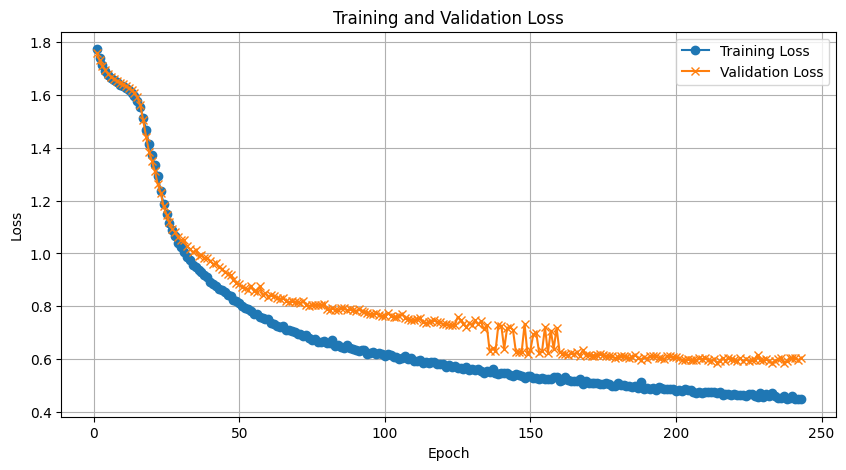

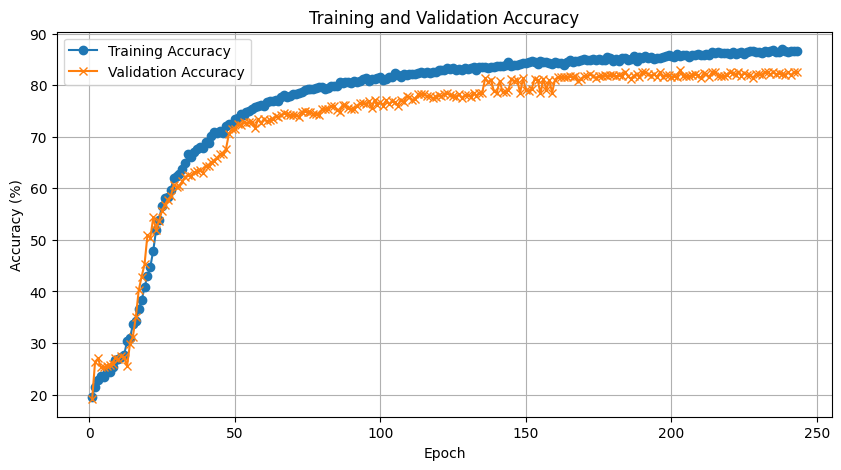

In [ ]:
# model17 showed some spikes in the training curve, thus we attempt to reduce learning rate a bit to further stabilise
model18 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=4e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history18 = model18.fit(train_iterator, valid_iterator, epochs=400, early_stopping=40)

plot_acc_loss_curves(history18)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model18_test_loss, model18_test_acc = model18.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model18_test_loss:.4f} | Test Accuracy: {model18_test_acc*100:.2f}%")



Testing model on test data...
Test Loss: 1.5689 | Test Accuracy: 61.93%


### Config 19: Freeze = True and Gradient Clipping
* learning rate = 0.00002
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.4 , L2 Regularisation (weight decay = 0.0001)

Epoch 01: Train Loss: 1.789, Train Acc: 17.64% | Val Loss: 1.776, Val Acc: 16.49%
Epoch 02: Train Loss: 1.770, Train Acc: 17.93% | Val Loss: 1.761, Val Acc: 16.67%
Epoch 03: Train Loss: 1.755, Train Acc: 18.50% | Val Loss: 1.749, Val Acc: 17.80%
Epoch 04: Train Loss: 1.740, Train Acc: 20.00% | Val Loss: 1.739, Val Acc: 20.92%
Epoch 05: Train Loss: 1.730, Train Acc: 21.48% | Val Loss: 1.730, Val Acc: 21.44%
Epoch 06: Train Loss: 1.721, Train Acc: 21.40% | Val Loss: 1.721, Val Acc: 22.83%
Epoch 07: Train Loss: 1.713, Train Acc: 22.13% | Val Loss: 1.714, Val Acc: 22.92%
Epoch 08: Train Loss: 1.706, Train Acc: 22.06% | Val Loss: 1.708, Val Acc: 24.05%
Epoch 09: Train Loss: 1.700, Train Acc: 22.52% | Val Loss: 1.702, Val Acc: 23.78%
Epoch 10: Train Loss: 1.698, Train Acc: 23.16% | Val Loss: 1.697, Val Acc: 23.18%
Epoch 11: Train Loss: 1.687, Train Acc: 23.46% | Val Loss: 1.692, Val Acc: 23.44%
Epoch 12: Train Loss: 1.684, Train Acc: 23.40% | Val Loss: 1.687, Val Acc: 23.26%
Epoch 13: Train 

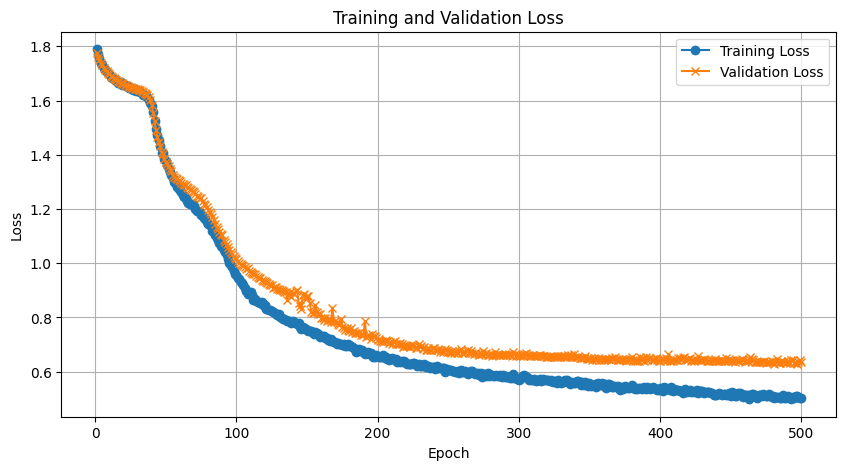

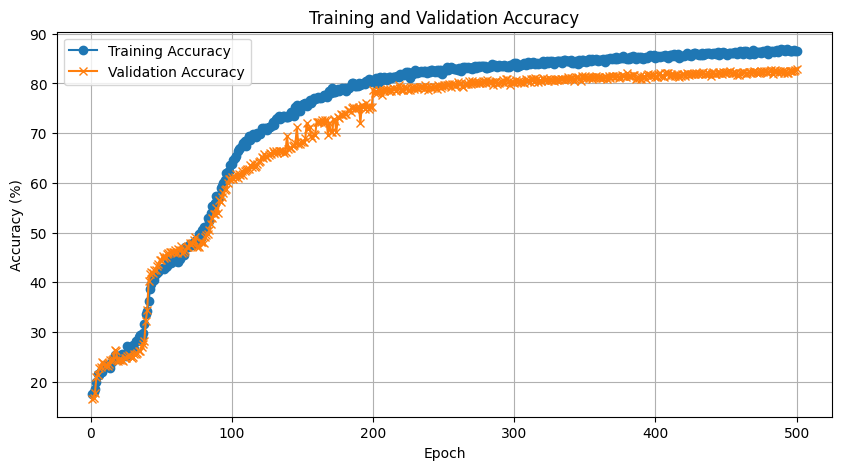

In [ ]:
# model17 showed some spikes in the training curve, thus we attempt to reduce learning rate a bit to further stabilise
model19 = RNNClassifierPlotterGrad(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=2e-5,
    dropout=0.4,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

# Train and evaluate
history19 = model19.fit(train_iterator, valid_iterator, epochs=500, early_stopping=40)

plot_acc_loss_curves(history19)

In [ ]:
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
model19_test_loss, model19_test_acc = model19.run_epoch(test_iterator, train=False)
print(f"Test Loss: {model19_test_loss:.4f} | Test Accuracy: {model19_test_acc*100:.2f}%")



Testing model on test data...
Test Loss: 1.2402 | Test Accuracy: 66.81%


Considering test accuracy and training vs validation accuracy the best result is achieved by model17 with the following configurations and a **test accuracy of 72.16%**:  
* learning rate = 0.00005
* optimizer = adam
* batch size = 64
* size of hidden layer = 64
* regularisation technique(s) = Dropout = 0.2, L2 Regularisation (weight decay = 0.0001)
* num epochs = 400 with patience = 40


## 2d) RNNs produce a hidden vector for each word, instead of the entire sentence
Which methods have you tried in deriving the final sentence representation to perform sentiment classification?
Describe all the strategies you have implemented, together with their accuracy scores on the
test set

### Mean pooling over hidden states

In [ ]:
"""
for ref, the base forward function:
def forward(self, text):
        embedded = self.embedding(text)
        outputs, hidden = self.rnn(embedded)

        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]
        sentence_rep = torch.cat((forward_hidden, backward_hidden), dim=1)
        sentence_rep = self.reg(sentence_rep)
        logits = self.fc(sentence_rep)
        return logits
"""
# Inherits RNNClassifier to modify fit to store histroy of training for plotting and
# sets freeze = true
class RNNMeanPool(RNNClassifier):

    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        self.to(self.device)

    def forward(self, text):
        embedded = self.embedding(text)
        outputs, hidden = self.rnn(embedded)

        # Mean-pool over sequence length (dim=1)
        sentence_rep = outputs.mean(dim=1)

        # Apply regularization based on the selected type
        if self.regularization == "dropout":
            sentence_rep = self.dropout_layer(sentence_rep)
        elif self.regularization == "layernorm":
            sentence_rep = self.layernorm_layer(sentence_rep)
        elif self.regularization == "both":
            sentence_rep = self.layernorm_layer(sentence_rep)
            sentence_rep = self.dropout_layer(sentence_rep)


        logits = self.fc(sentence_rep)
        return logits

    # run epoch with gradient clipping
    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            # Ensure text and labels have the same batch size
            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]


            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())


            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)


    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
          'train_loss': [],
          'train_acc': [],
          'val_loss': [],
          'val_acc': [],
          'epochs': 0
        }



        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)
            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history


Epoch 01: Train Loss: 1.756, Train Acc: 20.07% | Val Loss: 1.741, Val Acc: 19.10%
Epoch 02: Train Loss: 1.722, Train Acc: 23.10% | Val Loss: 1.708, Val Acc: 19.53%
Epoch 03: Train Loss: 1.686, Train Acc: 26.09% | Val Loss: 1.676, Val Acc: 19.70%
Epoch 04: Train Loss: 1.664, Train Acc: 26.19% | Val Loss: 1.651, Val Acc: 20.66%
Epoch 05: Train Loss: 1.638, Train Acc: 28.95% | Val Loss: 1.632, Val Acc: 21.96%
Epoch 06: Train Loss: 1.624, Train Acc: 30.07% | Val Loss: 1.617, Val Acc: 26.39%
Epoch 07: Train Loss: 1.604, Train Acc: 32.72% | Val Loss: 1.603, Val Acc: 28.56%
Epoch 08: Train Loss: 1.585, Train Acc: 34.25% | Val Loss: 1.584, Val Acc: 34.38%
Epoch 09: Train Loss: 1.562, Train Acc: 38.41% | Val Loss: 1.556, Val Acc: 36.98%
Epoch 10: Train Loss: 1.515, Train Acc: 42.77% | Val Loss: 1.500, Val Acc: 40.54%
Epoch 11: Train Loss: 1.435, Train Acc: 45.91% | Val Loss: 1.398, Val Acc: 46.27%
Epoch 12: Train Loss: 1.347, Train Acc: 48.23% | Val Loss: 1.333, Val Acc: 49.13%
Epoch 13: Train 

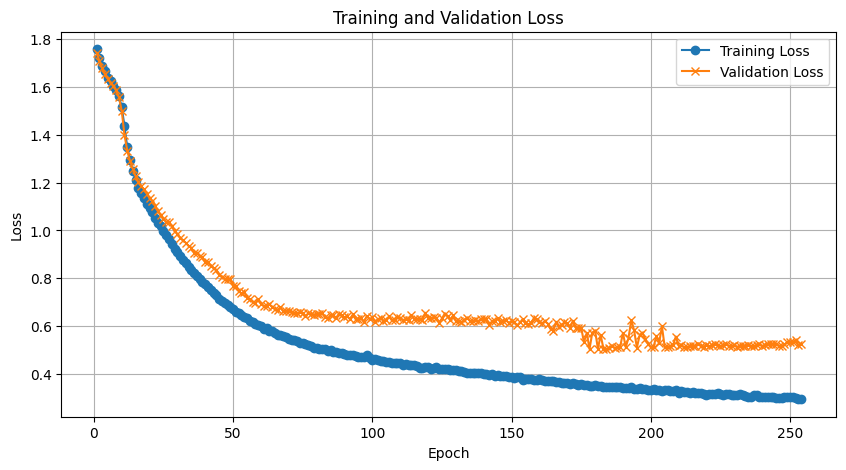

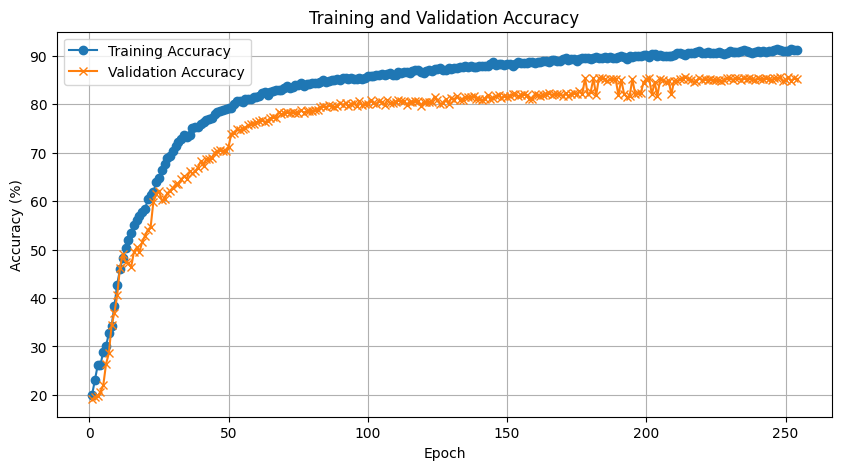


Testing model on test data...
Test Loss: 0.7445 | Test Accuracy: 72.03%


In [ ]:
# Using best config to see test accuracy
model17_meanpool = RNNMeanPool(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

meanpool_hist = model17_meanpool.fit(train_iterator, valid_iterator, epochs=400, early_stopping=40)
plot_acc_loss_curves(meanpool_hist)

# Evaluate trained model on test data
print(f"\nTesting model on test data...")
mean_pooling_test_loss, mean_pooling_test_acc = model17_meanpool.run_epoch(test_iterator, train=False)
print(f"Test Loss: {mean_pooling_test_loss:.4f} | Test Accuracy: {mean_pooling_test_acc*100:.2f}%")


### Max pooling over hidden states

In [ ]:
class RNNMaxPool(RNNClassifier):
    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        self.to(self.device)

    def forward(self, text):
        embedded = self.embedding(text)
        outputs, hidden = self.rnn(embedded)

        # Max-pool across sequence
        sentence_rep, _ = torch.max(outputs, dim=1)

        # Apply regularization based on the selected type
        if self.regularization == "dropout":
            sentence_rep = self.dropout_layer(sentence_rep)
        elif self.regularization == "layernorm":
            sentence_rep = self.layernorm_layer(sentence_rep)
        elif self.regularization == "both":
            sentence_rep = self.layernorm_layer(sentence_rep)
            sentence_rep = self.dropout_layer(sentence_rep)


        logits = self.fc(sentence_rep)
        return logits


    # run epoch with gradient clipping
    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            # Ensure text and labels have the same batch size
            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]


            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())


            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)


    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
          'train_loss': [],
          'train_acc': [],
          'val_loss': [],
          'val_acc': [],
          'epochs': 0
        }



        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)
            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history




Epoch 01: Train Loss: 1.814, Train Acc: 20.63% | Val Loss: 1.805, Val Acc: 20.14%
Epoch 02: Train Loss: 1.765, Train Acc: 24.79% | Val Loss: 1.757, Val Acc: 21.53%
Epoch 03: Train Loss: 1.723, Train Acc: 27.51% | Val Loss: 1.716, Val Acc: 25.00%
Epoch 04: Train Loss: 1.685, Train Acc: 29.72% | Val Loss: 1.680, Val Acc: 27.60%
Epoch 05: Train Loss: 1.655, Train Acc: 31.25% | Val Loss: 1.649, Val Acc: 30.30%
Epoch 06: Train Loss: 1.627, Train Acc: 34.52% | Val Loss: 1.620, Val Acc: 36.20%
Epoch 07: Train Loss: 1.605, Train Acc: 36.32% | Val Loss: 1.595, Val Acc: 40.80%
Epoch 08: Train Loss: 1.581, Train Acc: 38.64% | Val Loss: 1.573, Val Acc: 45.57%
Epoch 09: Train Loss: 1.560, Train Acc: 40.22% | Val Loss: 1.550, Val Acc: 46.44%
Epoch 10: Train Loss: 1.536, Train Acc: 42.26% | Val Loss: 1.528, Val Acc: 47.31%
Epoch 11: Train Loss: 1.510, Train Acc: 43.52% | Val Loss: 1.505, Val Acc: 48.52%
Epoch 12: Train Loss: 1.491, Train Acc: 45.72% | Val Loss: 1.482, Val Acc: 48.96%
Epoch 13: Train 

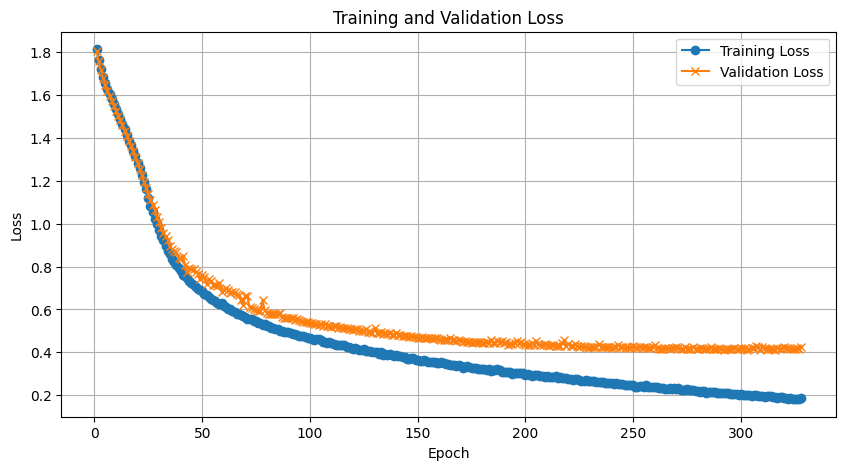

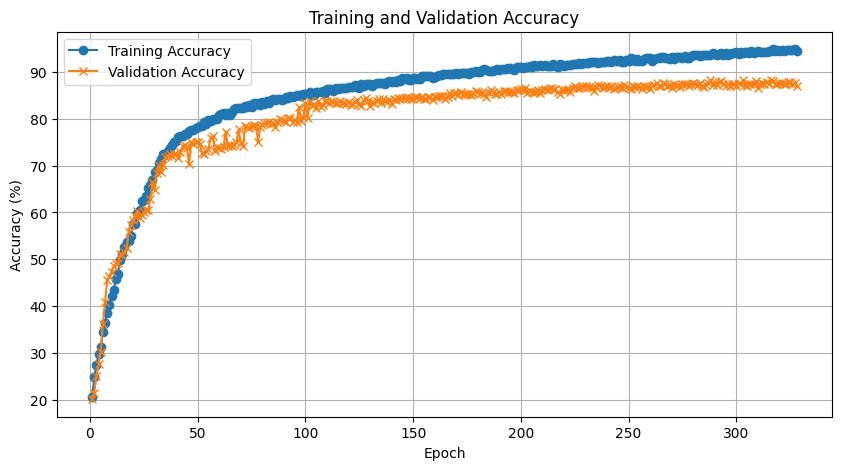


Testing model on test data...
Test Loss: 0.7129 | Test Accuracy: 70.94%


In [ ]:
model17_maxpool = RNNMaxPool(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5
)


maxpool_hist = model17_maxpool.fit(train_iterator, valid_iterator, epochs=400, early_stopping=40)
plot_acc_loss_curves(maxpool_hist)
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
max_pooling_test_loss, max_pooling_test_acc = model17_maxpool.run_epoch(test_iterator, train=False)
print(f"Test Loss: {max_pooling_test_loss:.4f} | Test Accuracy: {max_pooling_test_acc*100:.2f}%")

### Sum pooling over hidden states

In [ ]:
class RNNSumPool(RNNClassifier):
  def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        self.to(self.device)

  def forward(self, text):

    embedded = self.embedding(text)

    outputs, hidden = self.rnn(embedded)

    sentence_rep = torch.sum(outputs, dim=1)

    # Apply regularization based on the selected type
    if self.regularization == "dropout":
        sentence_rep = self.dropout_layer(sentence_rep)
    elif self.regularization == "layernorm":
        sentence_rep = self.layernorm_layer(sentence_rep)
    elif self.regularization == "both":
        sentence_rep = self.layernorm_layer(sentence_rep)
        sentence_rep = self.dropout_layer(sentence_rep)


    logits = self.fc(sentence_rep)
    return logits


    # run epoch with gradient clipping
  def run_epoch(self, iterator, train=True):
      epoch_loss, epoch_acc = 0, 0
      mode = "train" if train else "eval"
      getattr(self, mode)()

      for batch in iterator:
          text, labels = batch.text.to(self.device), batch.label.to(self.device)
          text = text.transpose(0, 1)

          # Ensure text and labels have the same batch size
          batch_size = min(text.shape[0], labels.shape[0])
          text = text[:batch_size]
          labels = labels[:batch_size]


          if train:
              self.optimizer.zero_grad()

          predictions = self.forward(text)
          loss = self.criterion(predictions, labels.squeeze())
          acc = self.accuracy(predictions, labels.squeeze())


          if train:
              loss.backward()
              torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
              self.optimizer.step()

          epoch_loss += loss.item()
          epoch_acc += acc.item()

      return epoch_loss / len(iterator), epoch_acc / len(iterator)


  def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
      best_val_acc = float("-inf")
      patience = 0
      history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'epochs': 0
      }



      for e in range(epochs):
          train_loss, train_acc = self.run_epoch(train_iterator, train=True)
          val_loss, val_acc = self.run_epoch(valid_iterator, train=False)
          # additional to store history
          history['train_loss'].append(train_loss)
          history['train_acc'].append(train_acc)
          history['val_loss'].append(val_loss)
          history['val_acc'].append(val_acc)
          history['epochs'] += 1

          print(f"Epoch {e+1:02}: "
                f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

          # Early stopping - stop when validation accuracy is not increasing
          if early_stopping:
              if val_acc > best_val_acc:
                  best_val_acc = val_acc
                  patience = 0
              else:
                  patience += 1
                  if patience >= early_stopping:
                      print(f"Early stopping triggered at epoch {e+1}.")
                      return history
      return history

Epoch 01: Train Loss: 1.780, Train Acc: 26.05% | Val Loss: 1.624, Val Acc: 29.43%
Epoch 02: Train Loss: 1.628, Train Acc: 30.29% | Val Loss: 1.538, Val Acc: 38.37%
Epoch 03: Train Loss: 1.527, Train Acc: 38.02% | Val Loss: 1.463, Val Acc: 42.97%
Epoch 04: Train Loss: 1.420, Train Acc: 44.01% | Val Loss: 1.394, Val Acc: 50.61%
Epoch 05: Train Loss: 1.345, Train Acc: 48.43% | Val Loss: 1.331, Val Acc: 54.25%
Epoch 06: Train Loss: 1.262, Train Acc: 52.74% | Val Loss: 1.236, Val Acc: 58.77%
Epoch 07: Train Loss: 1.182, Train Acc: 55.48% | Val Loss: 1.238, Val Acc: 58.33%
Epoch 08: Train Loss: 1.119, Train Acc: 59.83% | Val Loss: 1.209, Val Acc: 60.16%
Epoch 09: Train Loss: 1.065, Train Acc: 62.26% | Val Loss: 1.282, Val Acc: 59.46%
Epoch 10: Train Loss: 1.020, Train Acc: 63.81% | Val Loss: 1.341, Val Acc: 60.42%
Epoch 11: Train Loss: 0.977, Train Acc: 65.35% | Val Loss: 1.389, Val Acc: 61.98%
Epoch 12: Train Loss: 0.936, Train Acc: 67.28% | Val Loss: 1.411, Val Acc: 62.67%
Epoch 13: Train 

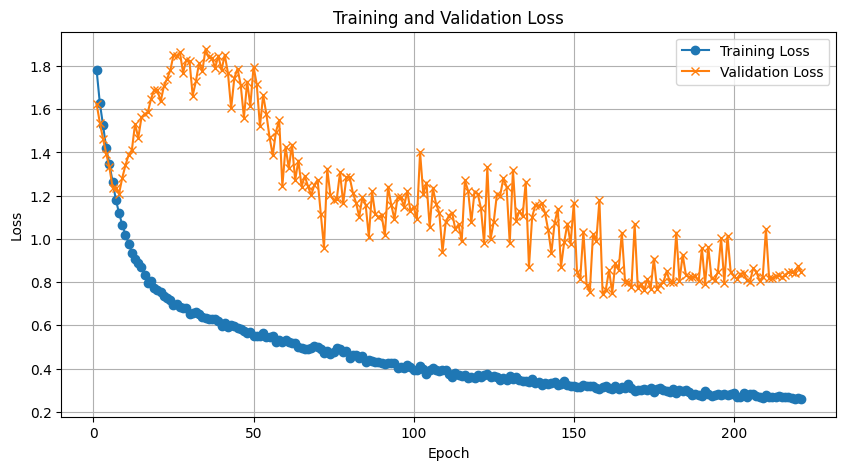

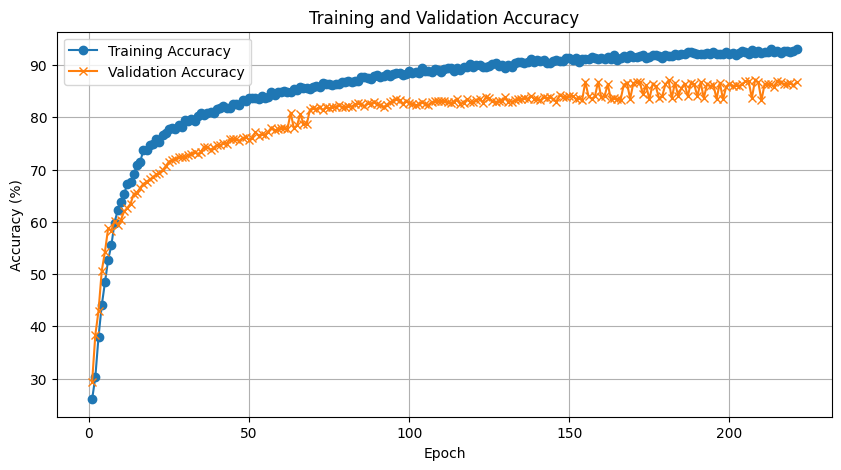


Testing model on test data...
Test Loss: 2.8975 | Test Accuracy: 64.75%


In [ ]:
# Using best config to see test accuracy

model17_sumpool = RNNSumPool(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

sumpool_hist = model17_sumpool.fit(train_iterator, valid_iterator, epochs=400, early_stopping=40)
plot_acc_loss_curves(sumpool_hist)
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
sum_pooling_test_loss, sum_pooling_test_acc = model17_sumpool.run_epoch(test_iterator, train=False)
print(f"Test Loss: {sum_pooling_test_loss:.4f} | Test Accuracy: {sum_pooling_test_acc*100:.2f}%")

We can see from the above accuracies that taking the final hidden state representation without pooling returns the highest test accuracy at 72.16%. Thus we use this model to measure topic-wise accuracies in the next part.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RNNHybridPool(RNNClassifier):
    def __init__(self, embedding_matrix, hidden_dim, output_dim,
                 lr=1e-3, dropout=0.5, regularization="dropout",
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            lr=lr,
            dropout=dropout,
            regularization=regularization,
            optimizer_type=optimizer_type,
            criterion_type=criterion_type,
            weight_decay=weight_decay,
            device=device
        )

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.fc = nn.Linear(hidden_dim * 3, output_dim)
        if self.regularization in ["layernorm", "both"]:
            self.layernorm_layer = nn.LayerNorm(hidden_dim * 3)
        else:
            self.layernorm_layer = nn.Identity()
        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)
        self.to(self.device)

    def forward(self, text):
        embedded = self.embedding(text)
        outputs, hidden = self.rnn(embedded)
        final_hidden_state = hidden[-1, :, :]
        mean_pooled = torch.mean(outputs, dim=1)
        max_pooled = torch.max(outputs, dim=1).values

        sentence_rep = torch.cat((final_hidden_state, mean_pooled, max_pooled), dim=1)

        if self.regularization == "dropout":
            sentence_rep = self.dropout_layer(sentence_rep)
        elif self.regularization == "layernorm":
            sentence_rep = self.layernorm_layer(sentence_rep)
        elif self.regularization == "both":
            sentence_rep = self.layernorm_layer(sentence_rep)
            sentence_rep = self.dropout_layer(sentence_rep)

        # 5. Pass through the new (larger) FC layer
        logits = self.fc(sentence_rep)
        return logits

    # run epoch with gradient clipping
    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            # Ensure text and labels have the same batch size
            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]


            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())


            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)



    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'epochs': 0
        }

        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)

            # additional to store history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            # Early stopping - stop when validation accuracy is not increasing
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

We attempt a hybrid pooling which instead of relying on one summary like only the final hidden state, combines 3 different summaries instead. Max pool finds the 'keywords' of the sentence, mean pool finds the idea or gist of the sentence. We concatenate these along with the final hidden state together to get a richer representation

Epoch 01: Train Loss: 1.826, Train Acc: 9.97% | Val Loss: 1.792, Val Acc: 19.36%
Epoch 02: Train Loss: 1.752, Train Acc: 22.96% | Val Loss: 1.734, Val Acc: 27.95%
Epoch 03: Train Loss: 1.702, Train Acc: 26.55% | Val Loss: 1.689, Val Acc: 31.34%
Epoch 04: Train Loss: 1.663, Train Acc: 29.18% | Val Loss: 1.654, Val Acc: 32.12%
Epoch 05: Train Loss: 1.627, Train Acc: 31.69% | Val Loss: 1.625, Val Acc: 32.47%
Epoch 06: Train Loss: 1.605, Train Acc: 33.22% | Val Loss: 1.599, Val Acc: 33.59%
Epoch 07: Train Loss: 1.578, Train Acc: 35.70% | Val Loss: 1.575, Val Acc: 34.29%
Epoch 08: Train Loss: 1.555, Train Acc: 38.11% | Val Loss: 1.547, Val Acc: 39.24%
Epoch 09: Train Loss: 1.516, Train Acc: 42.95% | Val Loss: 1.511, Val Acc: 43.06%
Epoch 10: Train Loss: 1.471, Train Acc: 46.35% | Val Loss: 1.451, Val Acc: 47.92%
Epoch 11: Train Loss: 1.390, Train Acc: 49.89% | Val Loss: 1.349, Val Acc: 49.65%
Epoch 12: Train Loss: 1.306, Train Acc: 50.37% | Val Loss: 1.285, Val Acc: 49.13%
Epoch 13: Train L

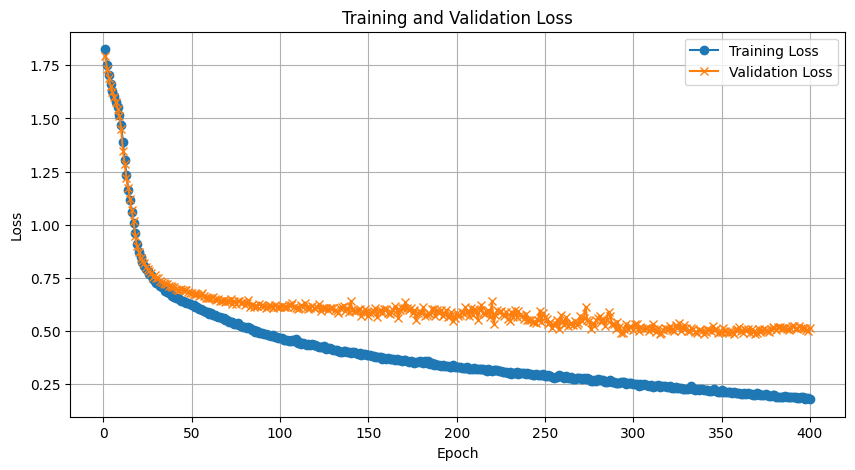

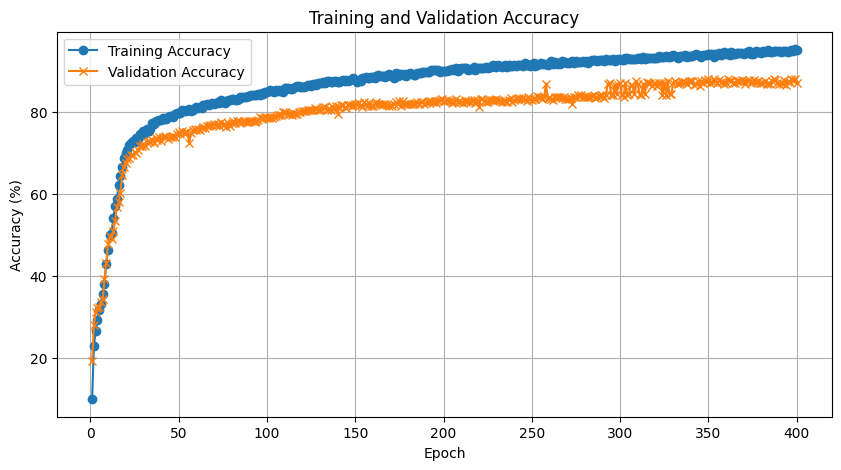


Testing model on test data...
Test Loss: 0.6219 | Test Accuracy: 83.28%


In [ ]:
# Using best config to see test accuracy

model17_hybridpool = RNNHybridPool(
    embedding_matrix=embedding_matrix_hybrid,
    hidden_dim=64,
    output_dim=len(LABEL.vocab),
    lr=5e-5,
    dropout=0.2,
    regularization="dropout",   # "dropout", "layernorm", "none"
    optimizer_type="adam",   # "adam", "sgd", "rmsprop"
    criterion_type="crossentropy",  # "crossentropy", "nll", "mse"
    weight_decay=1e-5

)

hybridpool_hist = model17_hybridpool.fit(train_iterator, valid_iterator, epochs=400, early_stopping=40)
plot_acc_loss_curves(hybridpool_hist)
# Evaluate trained model on test data
print(f"\nTesting model on test data...")
hybrid_pooling_test_loss, hybrid_pooling_test_acc = model17_hybridpool.run_epoch(test_iterator, train=False)
print(f"Test Loss: {hybrid_pooling_test_loss:.4f} | Test Accuracy: {hybrid_pooling_test_acc*100:.2f}%")

In [ ]:
#print accuracies
print(f"Best Config Test Accuracy: {model17_test_acc*100:.2f}%")
print(f"Mean Pooling Test Accuracy: {mean_pooling_test_acc*100:.2f}%")
print(f"Max Pooling Test Accuracy: {max_pooling_test_acc*100:.2f}%")
print(f"Sum Pooling Test Accuracy: {sum_pooling_test_acc*100:.2f}%")
print(f"Hybrid Pooling Test Accuracy: {hybrid_pooling_test_acc*100:.2f}%")


Best Config Test Accuracy: 72.16%
Mean Pooling Test Accuracy: 72.03%
Max Pooling Test Accuracy: 70.94%
Sum Pooling Test Accuracy: 64.75%
Hybrid Pooling Test Accuracy: 83.28%


## 2e) Topic-wise accuracy

It is clear that the hybrid pooling produces the highest accuracy on the test dataset thus we use this model to evaluate topicwise accuracy

In [ ]:
from collections import defaultdict

def measure_topicwise_accuracy(model, test_iterator, label_field):
    model.eval()
    correct = defaultdict(int)
    total = defaultdict(int)

    # Map label indices to human-readable names
    label_names = label_field.vocab.itos

    with torch.no_grad():
        for batch in test_iterator:
            text, labels = batch.text.to(model.device), batch.label.to(model.device)
            text = text.transpose(0, 1)

            preds = model(text)
            max_preds = preds.argmax(dim=1)

            for pred, true in zip(max_preds.cpu(), labels.cpu()):
                total[true.item()] += 1
                if pred == true:
                    correct[true.item()] += 1

    print("Topic-wise Accuracy on Test Set:")
    print("--------------------------------")
    for i, label in enumerate(label_names):
        if total[i] > 0:
            acc = correct[i] / total[i]
            print(f"{label:5s}: {acc * 100:.2f}% ({correct[i]}/{total[i]})")
        else:
            print(f"{label:5s}: No samples found.")


In [ ]:
measure_topicwise_accuracy(model17_hybridpool, test_iterator, LABEL)


Topic-wise Accuracy on Test Set:
--------------------------------
HUM  : 95.38% (62/65)
ENTY : 70.21% (66/94)
DESC : 77.54% (107/138)
NUM  : 92.04% (104/113)
LOC  : 86.42% (70/81)
ABBR : 77.78% (7/9)


# Part 3. Enhancement

### 3.2. Replace your simple RNN model in Part 2 with a Convolutional Neural Network (CNN) to produce sentence representations and perform topic classification

#### 3(b) Plot the training loss curve and validation accuracy curve of CNN. Report its accuracy score on the test set (Part 3.2).

In [ ]:
class CNNClassifier(nn.Module):
    """
    CNN text classifier, including all helper methods for
    training, evaluation, and plotting.
    """
    def __init__(self, embedding_matrix, output_dim, n_filters, filter_sizes,
                 dropout, lr=1e-3, optimizer_type="adam",
                 criterion_type="crossentropy", weight_decay=1e-5, device=None):

        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        vocab_size, embedding_dim = embedding_matrix.shape

        # 1. Embedding Layer (from_pretrained, learnable)
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )

        # 2. Convolutional Layers
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels = embedding_dim,
                      out_channels = n_filters,
                      kernel_size = fs)
            for fs in filter_sizes
        ])

        # 3. Fully Connected Layer
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)

        # 4. Dropout
        self.dropout = nn.Dropout(dropout)

        # 5. Criterion
        self.criterion = self._init_criterion(criterion_type)

        # 6. Optimizer
        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        # Move to device
        self.to(self.device)

    def forward(self, text):
        # text shape: (batch_size, seq_len)

        embedded = self.embedding(text)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        # Conv1d expects (batch_size, in_channels, seq_len)
        embedded = embedded.permute(0, 2, 1)
        # embedded shape: (batch_size, embedding_dim, seq_len)

        conved = [F.relu(conv(embedded)) for conv in self.convs]
        # conved[i] shape: (batch_size, n_filters, seq_len - filter_sizes[i] + 1)

        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        # pooled[i] shape: (batch_size, n_filters)

        catted = torch.cat(pooled, dim=1)
        # catted shape: (batch_size, n_filters * len(filter_sizes))

        dropped = self.dropout(catted)
        logits = self.fc(dropped)

        return logits

    # --- Helper methods (These were missing from the class in the last turn) ---

    def _init_criterion(self, criterion_type):
        ct = criterion_type.lower()
        if ct == "crossentropy":
            return nn.CrossEntropyLoss()
        elif ct == "nll":
            return nn.NLLLoss()
        elif ct == "mse":
            return nn.MSELoss()
        else:
            raise ValueError(f"Unsupported criterion: {criterion_type}")

    def _init_optimizer(self, optimizer_type, lr, weight_decay):
        ot = optimizer_type.lower()
        if ot == "adam":
            return torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        elif ot == "sgd":
            return torch.optim.SGD(self.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        elif ot == "rmsprop":
            return torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_type}")

    def accuracy(self, preds, y):
        max_preds = preds.argmax(dim=1, keepdim=True)
        correct = max_preds.squeeze(1).eq(y)
        return correct.sum().float() / y.shape[0]

    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)() # Sets model to train() or eval()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)

            # BucketIterator default is (seq_len, batch_size)
            # We transpose to (batch_size, seq_len) for CNN
            text = text.transpose(0, 1)

            batch_size = min(text.shape[0], labels.shape[0])
            # text = text[:batch_size]
            # labels = labels[:batch_size]

            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())

            if train:
                loss.backward()
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)

    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0

        history = {
          'train_loss': [], 'train_acc': [],
          'val_loss': [], 'val_acc': [], 'epochs': 0
        }

        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)

            # Store history for plotting
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

In [ ]:
def plot_acc_loss_curves(history, model_name="Model"):
  """Plots the training/validation loss and accuracy curves."""
  num_epochs = history['epochs']
  epochs_list = range(1, num_epochs + 1)

  # Plot 1: Loss Curve
  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, history['train_loss'], label='Training Loss', marker='o')
  plt.plot(epochs_list, history['val_loss'], label='Validation Loss', marker='x')
  plt.title(f'Training and Validation Loss ({model_name})')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Plot 2: Accuracy Curve
  plt.figure(figsize=(10, 5))
  plt.plot(epochs_list, [acc * 100 for acc in history['train_acc']], label='Training Accuracy', marker='o')
  plt.plot(epochs_list, [acc * 100 for acc in history['val_acc']], label='Validation Accuracy', marker='x')
  plt.title(f'Training and Validation Accuracy ({model_name})')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()
  plt.grid(True)
  plt.show()

--- Training CNN Model (Part 3.2) ---
Epoch 01: Train Loss: 1.624, Train Acc: 52.57% | Val Loss: 1.456, Val Acc: 79.69%
Epoch 02: Train Loss: 1.268, Train Acc: 79.74% | Val Loss: 1.121, Val Acc: 83.94%
Epoch 03: Train Loss: 0.964, Train Acc: 84.12% | Val Loss: 0.878, Val Acc: 83.68%
Epoch 04: Train Loss: 0.771, Train Acc: 86.27% | Val Loss: 0.739, Val Acc: 84.03%
Epoch 05: Train Loss: 0.626, Train Acc: 88.67% | Val Loss: 0.653, Val Acc: 84.20%
Epoch 06: Train Loss: 0.547, Train Acc: 89.59% | Val Loss: 0.598, Val Acc: 84.03%
Epoch 07: Train Loss: 0.488, Train Acc: 90.66% | Val Loss: 0.559, Val Acc: 83.68%
Epoch 08: Train Loss: 0.431, Train Acc: 91.36% | Val Loss: 0.537, Val Acc: 84.03%
Epoch 09: Train Loss: 0.401, Train Acc: 92.18% | Val Loss: 0.519, Val Acc: 84.55%
Epoch 10: Train Loss: 0.363, Train Acc: 92.83% | Val Loss: 0.506, Val Acc: 85.07%
Epoch 11: Train Loss: 0.329, Train Acc: 93.41% | Val Loss: 0.497, Val Acc: 82.20%
Epoch 12: Train Loss: 0.303, Train Acc: 93.75% | Val Loss: 0

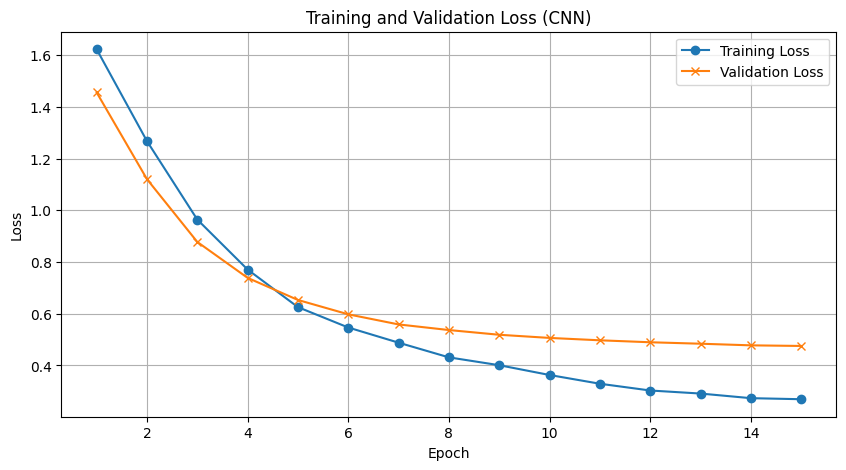

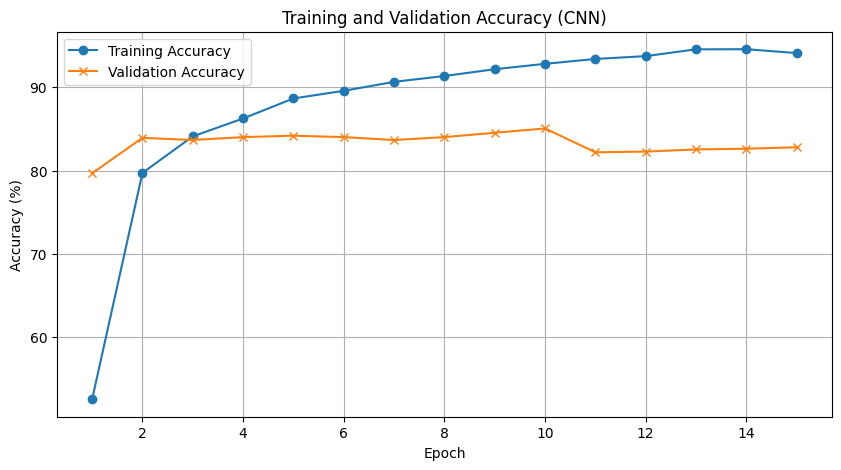


--- Testing CNN model on test data (Q3b) ---
Test Loss: 0.4434 | Test Accuracy: 87.71%


In [ ]:
# --- Part 3(b). Train and Evaluate CNN ---

# Define Hyperparameters
OUTPUT_DIM = len(LABEL.vocab)
N_FILTERS = 64
FILTER_SIZES = [2, 3, 4]  # Use 3 different n-gram filters
DROPOUT = 0.8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Instantiate the CNN model
model_cnn = CNNClassifier(
    embedding_matrix=embedding_matrix_hybrid,
    output_dim=OUTPUT_DIM,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    dropout=DROPOUT,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("--- Training CNN Model (Part 3.2) ---")

# Train and evaluate
cnn_history = model_cnn.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# --- Q3(b) Plotting ---
print("\n--- CNN Training/Validation Curves (Q3b) ---")
plot_acc_loss_curves(cnn_history, model_name="CNN")

# --- Q3(b) Final Accuracy ---
print("\n--- Testing CNN model on test data (Q3b) ---")
cnn_test_loss, cnn_test_acc = model_cnn.run_epoch(test_iterator, train=False)
print(f"Test Loss: {cnn_test_loss:.4f} | Test Accuracy: {cnn_test_acc*100:.2f}%")

### 3.3 Further improve your model. You are free to use any strategy other than the above mentioned solutions. Changing hyper-parameters or stacking more layers is not counted towards a meaningful improvement.

Proposed improvement: Hybrid CNN-biLSTM Model

this part need to refine the test results not as good as previous parts.

In [ ]:
class HybridCnnLstmClassifier(nn.Module):
    """
    Improved Hybrid CNN-biLSTM model with strong regularization.
    Designed to prevent overfitting on smaller datasets.
    """
    def __init__(self, embedding_matrix, output_dim, n_filters, filter_sizes,
                 hidden_dim, n_layers, dropout, lr=1e-3,
                 optimizer_type="adam", criterion_type="crossentropy",
                 weight_decay=1e-5, device=None):

        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        vocab_size, embedding_dim = embedding_matrix.shape

        # 1. Shared Embedding Layer with dropout
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )
        self.embedding_dropout = nn.Dropout(dropout * 0.5)  # Light dropout on embeddings

        # --- 2. CNN Path ---
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                      out_channels=n_filters,
                      kernel_size=fs)
            for fs in filter_sizes
        ])

        # Batch normalization after CNN
        cnn_output_dim = len(filter_sizes) * n_filters
        self.cnn_bn = nn.BatchNorm1d(cnn_output_dim)

        # --- 3. biLSTM Path ---
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )

        lstm_output_dim = hidden_dim * 2
        self.lstm_bn = nn.BatchNorm1d(lstm_output_dim)

        # 4. Multiple dropout layers
        self.cnn_dropout = nn.Dropout(dropout)
        self.lstm_dropout = nn.Dropout(dropout)
        self.combined_dropout = nn.Dropout(dropout)

        # 5. Optional: Add an intermediate layer to reduce overfitting
        intermediate_dim = (cnn_output_dim + lstm_output_dim) // 2
        self.fc1 = nn.Linear(cnn_output_dim + lstm_output_dim, intermediate_dim)
        self.fc1_bn = nn.BatchNorm1d(intermediate_dim)
        self.fc1_dropout = nn.Dropout(dropout)

        # 6. Final output layer
        self.fc2 = nn.Linear(intermediate_dim, output_dim)

        # 7. Criterion & Optimizer
        self.criterion = self._init_criterion(criterion_type)
        self.optimizer = self._init_optimizer(optimizer_type, lr, weight_decay)

        # Move to device
        self.to(self.device)

    def forward(self, text):
        # text shape: (batch_size, seq_len)

        embedded = self.embedding(text)
        embedded = self.embedding_dropout(embedded)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        # --- CNN Path ---
        embedded_cnn = embedded.permute(0, 2, 1)
        conved = [F.relu(conv(embedded_cnn)) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]

        cnn_features = torch.cat(pooled, dim=1)
        cnn_features = self.cnn_bn(cnn_features)
        cnn_features = self.cnn_dropout(cnn_features)

        # --- biLSTM Path ---
        outputs_lstm, (hidden, cell) = self.lstm(embedded)

        # Max pooling over LSTM outputs
        lstm_pooled = torch.max(outputs_lstm, dim=1)[0]

        lstm_features = self.lstm_bn(lstm_pooled)
        lstm_features = self.lstm_dropout(lstm_features)

        # --- Combine Paths ---
        combined_features = torch.cat((cnn_features, lstm_features), dim=1)
        combined_features = self.combined_dropout(combined_features)

        # Intermediate layer with activation
        hidden = F.relu(self.fc1(combined_features))
        hidden = self.fc1_bn(hidden)
        hidden = self.fc1_dropout(hidden)

        # Output layer
        logits = self.fc2(hidden)

        return logits

    def _init_criterion(self, criterion_type):
        ct = criterion_type.lower()
        if ct == "crossentropy":
            return nn.CrossEntropyLoss()
        else:
            raise ValueError(f"Unsupported criterion: {criterion_type}")

    def _init_optimizer(self, optimizer_type, lr, weight_decay):
        ot = optimizer_type.lower()
        if ot == "adam":
            return torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        elif ot == "adamw":
            return torch.optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_type}")

    def accuracy(self, preds, y):
        max_preds = preds.argmax(dim=1, keepdim=True)
        correct = max_preds.squeeze(1).eq(y)
        return correct.sum().float() / y.shape[0]

    def run_epoch(self, iterator, train=True):
        epoch_loss, epoch_acc = 0, 0
        mode = "train" if train else "eval"
        getattr(self, mode)()

        for batch in iterator:
            text, labels = batch.text.to(self.device), batch.label.to(self.device)
            text = text.transpose(0, 1)

            batch_size = min(text.shape[0], labels.shape[0])
            text = text[:batch_size]
            labels = labels[:batch_size]

            if train:
                self.optimizer.zero_grad()

            predictions = self.forward(text)
            loss = self.criterion(predictions, labels.squeeze())
            acc = self.accuracy(predictions, labels.squeeze())

            if train:
                loss.backward()
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                self.optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(iterator), epoch_acc / len(iterator)

    def fit(self, train_iterator, valid_iterator, epochs=10, early_stopping=None):
        best_val_acc = float("-inf")
        patience = 0
        history = {
          'train_loss': [], 'train_acc': [],
          'val_loss': [], 'val_acc': [], 'epochs': 0
        }

        for e in range(epochs):
            train_loss, train_acc = self.run_epoch(train_iterator, train=True)
            val_loss, val_acc = self.run_epoch(valid_iterator, train=False)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['epochs'] += 1

            print(f"Epoch {e+1:02}: "
                  f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%")

            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience = 0
                else:
                    patience += 1
                    if patience >= early_stopping:
                        print(f"Early stopping triggered at epoch {e+1}.")
                        return history
        return history

--- Training Hybrid CNN-biLSTM Model (Part 3.3) ---
Epoch 01: Train Loss: 1.912, Train Acc: 22.60% | Val Loss: 1.805, Val Acc: 25.35%
Epoch 02: Train Loss: 1.628, Train Acc: 35.31% | Val Loss: 1.442, Val Acc: 47.57%
Epoch 03: Train Loss: 1.361, Train Acc: 48.29% | Val Loss: 1.205, Val Acc: 59.72%
Epoch 04: Train Loss: 1.129, Train Acc: 60.96% | Val Loss: 0.982, Val Acc: 69.36%
Epoch 05: Train Loss: 0.933, Train Acc: 69.53% | Val Loss: 0.834, Val Acc: 75.52%
Epoch 06: Train Loss: 0.805, Train Acc: 74.82% | Val Loss: 0.746, Val Acc: 77.86%
Epoch 07: Train Loss: 0.673, Train Acc: 80.60% | Val Loss: 0.660, Val Acc: 78.91%
Epoch 08: Train Loss: 0.576, Train Acc: 84.16% | Val Loss: 0.609, Val Acc: 80.30%
Epoch 09: Train Loss: 0.500, Train Acc: 87.13% | Val Loss: 0.583, Val Acc: 80.90%
Epoch 10: Train Loss: 0.438, Train Acc: 87.88% | Val Loss: 0.553, Val Acc: 80.82%
Epoch 11: Train Loss: 0.397, Train Acc: 89.50% | Val Loss: 0.549, Val Acc: 81.16%
Epoch 12: Train Loss: 0.346, Train Acc: 91.10%

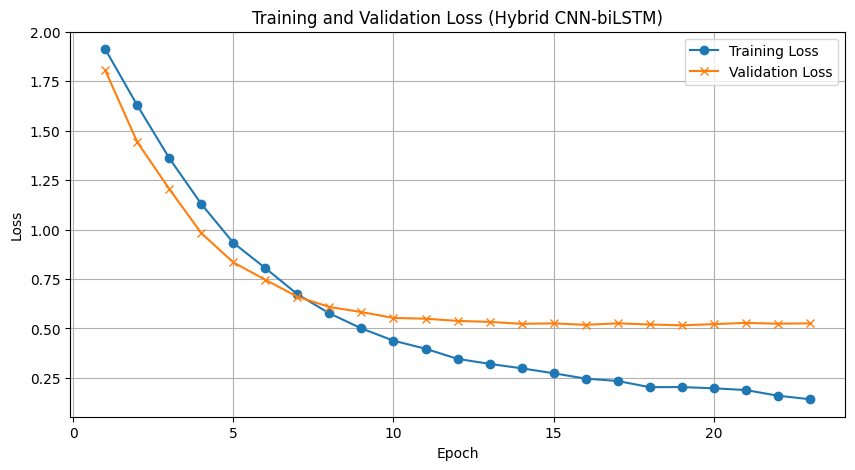

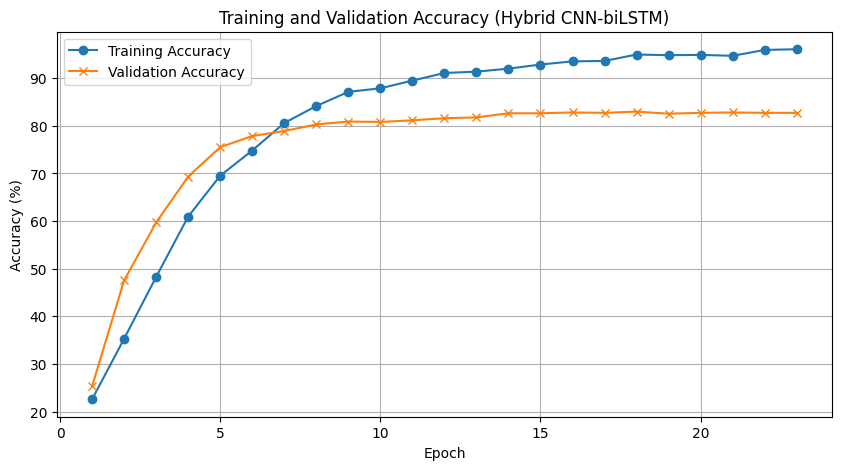


--- Testing Hybrid model on test data (Q3c) ---
Test Loss: 0.3940 | Test Accuracy: 86.25%


In [ ]:
# --- Part 3(c). Train and Evaluate Hybrid Model ---

# Define Hyperparameters
OUTPUT_DIM = len(LABEL.vocab)
# CNN params
N_FILTERS = 50
FILTER_SIZES = [2, 3, 4]
# LSTM params
HIDDEN_DIM = 64
N_LAYERS = 2 # Stacked biLSTM
# Shared params
DROPOUT = 0.6
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3

# Instantiate the Hybrid model
model_hybrid = HybridCnnLstmClassifier(
    embedding_matrix = embedding_matrix_hybrid,
    output_dim = OUTPUT_DIM,
    n_filters = N_FILTERS,
    filter_sizes = FILTER_SIZES,
    hidden_dim = HIDDEN_DIM,
    n_layers = N_LAYERS,
    dropout = DROPOUT,
    lr = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

print("--- Training Hybrid CNN-biLSTM Model (Part 3.3) ---")

# Train and evaluate
hybrid_history = model_hybrid.fit(train_iterator, valid_iterator, epochs=30, early_stopping=5)

# --- Q3(c) Plotting ---
print("\n--- Hybrid Model Training/Validation Curves (Q3c) ---")
plot_acc_loss_curves(hybrid_history, model_name="Hybrid CNN-biLSTM")

# --- Q3(c) Final Accuracy ---
print("\n--- Testing Hybrid model on test data (Q3c) ---")
hybrid_test_loss, hybrid_test_acc = model_hybrid.run_epoch(test_iterator, train=False)
print(f"Test Loss: {hybrid_test_loss:.4f} | Test Accuracy: {hybrid_test_acc*100:.2f}%")